In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader as TorchDataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from tqdm import tqdm
import warnings
import os
import platform

In [2]:
# 설정
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)
print(f"사용 디바이스: {device}")

사용 디바이스: cpu


In [3]:
# 한글 폰트 설정
def setup_korean_font():
    """운영체제별 한글 폰트 자동 설정"""
    system = platform.system()
    try:
        if system == 'Windows':
            fonts = ['Malgun Gothic', 'gulim', 'dotum']
        elif system == 'Darwin':  # macOS
            fonts = ['AppleGothic', 'Arial Unicode MS']
        else:  # Linux
            fonts = ['Noto Sans CJK KR', 'NanumGothic']
        
        for font in fonts:
            try:
                plt.rcParams['font.family'] = font
                fig, ax = plt.subplots(figsize=(1, 1))
                ax.text(0.5, 0.5, '테스트', fontsize=8)
                plt.close(fig)
                plt.rcParams['axes.unicode_minus'] = False
                print(f"✅ 한글 폰트 설정: {font}")
                return True
            except:
                continue
        
        plt.rcParams['font.family'] = 'DejaVu Sans'
        print("⚠️ 한글 폰트 설정 실패, 영어 라벨 사용")
        return False
    except:
        plt.rcParams['font.family'] = 'DejaVu Sans'
        return False

korean_font_available = setup_korean_font()

✅ 한글 폰트 설정: Malgun Gothic


In [4]:
# =============================================================================
# 1. 감정 설정 클래스
# =============================================================================

class EmotionConfig:
    """감정 설정 및 매핑 클래스"""
    
    def __init__(self):
        # 감정 카테고리 정의 (인사이드아웃 2 기반)
        self.emotions = {
            'joy': {'valence': (0.8, 1.0), 'energy_weight': 0.7, 'label': '기쁨이'},
            'sadness': {'valence': (0.0, 0.25), 'energy_weight': 0.2, 'label': '슬픔이'},
            'boredom': {'valence': (0.4, 0.6), 'energy_weight': 0.1, 'label': '따분이'},
            'anxiety': {'valence': (0.1, 0.4), 'energy_weight': 0.5, 'label': '소심이'},
            'anger': {'valence': (0.0, 0.3), 'energy_weight': 0.8, 'label': '버럭이'},
            'grumpy': {'valence': (0.3, 0.5), 'energy_weight': 0.5, 'label': '까칠이'},
            'fear': {'valence': (0.0, 0.2), 'energy_weight': 0.9, 'label': '불안이'},
            'embarrassment': {'valence': (0.5, 0.75), 'energy_weight': 0.3, 'label': '당황이'},
            'envy': {'valence': (0.2, 0.4), 'energy_weight': 0.4, 'label': '부럽이'},
            'calm': {'valence': (0.4, 0.75), 'energy_weight': 0.3, 'label': '평온'},
        }
        
        # 한국어 감정 키워드 매핑
        self.korean_emotion_map = {
            '기쁨': 'joy', '환희': 'joy', '즐거움': 'joy', '행복': 'joy', '만족': 'joy',
            '신나는': 'joy', '기쁜': 'joy', '즐거운': 'joy', '행복한': 'joy', '좋은': 'joy',
            '슬픔': 'sadness', '우울': 'sadness', '좌절': 'sadness', '비참': 'sadness',
            '슬픈': 'sadness', '우울한': 'sadness', '외로운': 'sadness', '그리움': 'sadness',
            '지루함': 'boredom', '따분': 'boredom', '심심': 'boredom', '무기력': 'boredom',
            '불안': 'anxiety', '걱정': 'anxiety', '초조': 'anxiety', '긴장': 'anxiety', '스트레스': 'anxiety',
            '화남': 'anger', '분노': 'anger', '짜증': 'anger', '버럭': 'anger', '화난': 'anger',
            '까칠': 'grumpy', '예민': 'grumpy', '불쾌': 'grumpy',
            '두려움': 'fear', '공포': 'fear', '무서움': 'fear', '겁': 'fear',
            '당황': 'embarrassment', '어색': 'embarrassment', '민망': 'embarrassment',
            '부러움': 'envy', '질투': 'envy',
            '평온': 'calm', '차분': 'calm', '안정': 'calm', '편안': 'calm', '여유': 'calm',
        }
    
    def classify_emotion(self, valence, energy):
        """Valence-Energy 값으로 감정 분류"""
        if valence >= 0.8 and energy >= 0.7:
            return 'joy'
        elif valence < 0.2 and energy >= 0.85:
            return 'fear'
        elif valence < 0.3 and energy >= 0.7:
            return 'anger'
        elif 0.2 <= valence < 0.4 and energy >= 0.4:
            return 'envy'
        elif 0.1 <= valence < 0.4 and energy >= 0.5:
            return 'anxiety'
        elif valence < 0.25 and energy < 0.3:
            return 'sadness'
        elif 0.4 <= valence < 0.6 and energy < 0.2:
            return 'boredom'
        elif 0.3 <= valence < 0.5 and energy >= 0.5:
            return 'grumpy'
        elif 0.5 <= valence < 0.75 and energy < 0.4:
            return 'embarrassment'
        else:
            return 'calm'
    
    def get_emotion_label(self, emotion_key):
        """감정 키에 대한 한국어 라벨 반환"""
        return self.emotions.get(emotion_key, {'label': '알 수 없음'})['label']
    
    def map_korean_emotion(self, korean_text):
        """한국어 텍스트에서 감정 매핑"""
        for keyword, emotion in self.korean_emotion_map.items():
            if keyword in korean_text:
                return emotion, keyword
        return None, None


In [5]:
# =============================================================================
# 2. 신경망 모델
# =============================================================================

class MusicEmotionClassifier(nn.Module):
    """음악 감정 분류를 위한 신경망 모델"""
    
    def __init__(self, input_dim, hidden_layers=[256, 128, 64], num_classes=10, dropout=0.3):
        super(MusicEmotionClassifier, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for i, hidden_dim in enumerate(hidden_layers):
            layers.extend([
                nn.Linear(prev_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout if i < len(hidden_layers)-1 else dropout/2)
            ])
            prev_dim = hidden_dim
        
        layers.extend([
            nn.Linear(prev_dim, num_classes),
            nn.Softmax(dim=1)
        ])
        
        self.network = nn.Sequential(*layers)
        self._initialize_weights()
    
    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)
    
    def forward(self, x):
        return self.network(x)


In [6]:
# =============================================================================
# 3. 가사 감정 분석 클래스
# =============================================================================

class LyricsAnalyzer:
    """가사 감정 분석 클래스"""
    
    def __init__(self, emotion_config):
        self.emotion_config = emotion_config
        
        # 감정별 키워드 확장
        self.emotion_keywords = {
            'joy': ['행복', '기쁨', '즐거', '좋', '신나', '웃음', '사랑', '최고', '완벽', '축하', 
                   '기뻐', '만족', '설레', '환상', '놀라운', '멋진', '예쁜', '아름다운', '달콤'],
            'sadness': ['슬픔', '아픔', '눈물', '이별', '그리', '외로', '아쉬', '후회', '비참',
                       '우울', '힘들', '아프', '떠나', '헤어', '잃', '그립', '쓸쓸', '공허'],
            'anger': ['화', '분노', '짜증', '열받', '배신', '억울', '복수', '스트레스', '빡',
                     '미워', '싫어', '죽이', '때리', '부수', '파괴', '증오', '원망'],
            'anxiety': ['걱정', '불안', '긴장', '떨', '두려', '초조', '압박', '스트레스',
                       '무서', '겁나', '조심', '신경', '예민', '조급'],
            'calm': ['평온', '차분', '고요', '휴식', '편안', '평화', '안정', '여유',
                    '조용', '느긋', '천천히', '쉬', '잠', '명상', '자연'],
            'fear': ['무서', '두려', '겁', '공포', '위험', '떨',
                    '무서워', '겁나', '놀라', '충격', '당황'],
            'boredom': ['지루', '심심', '따분', '재미없', '밋밋', '단조',
                       '지겨', '뻔하', '똑같', '반복'],
            'grumpy': ['기분나빠', '예민', '까칠', '신경질', '토라',
                      '짜증나', '불쾌', '못마땅'],
            'embarrassment': ['부끄', '당황', '어색', '민망', '머쓱',
                             '창피', '수줍', '얼굴'],
            'envy': ['부러', '질투', '시기', '선망',
                    '부럽', '질투나', '시샘']
        }
    
    def generate_sample_lyrics(self, emotion, n_samples=1):
        """감정별 샘플 가사 생성"""
        lyrics_templates = {
            'joy': [
                "오늘은 정말 행복한 날이야 사랑하는 사람과 함께 웃음이 끊이지 않아",
                "기쁨이 넘쳐흘러 하늘을 날 것 같아 모든 것이 완벽해",
                "신나는 음악에 맞춰 춤을 춰봐 행복한 순간을 만끽해",
                "사랑스러운 그대와 함께하는 시간 세상에서 가장 달콤해"
            ],
            'sadness': [
                "이별한 사람이 그리워 눈물이 흘러 외로운 밤을 보내고 있어",
                "아픈 마음을 달래줄 사람은 없고 슬픔만이 나를 감싸네",
                "떠나간 사람을 생각하며 후회하는 마음 아직도 사랑해",
                "빈 방에 혼자 남겨진 채 그리움에 잠 못 이루네"
            ],
            'anger': [
                "화가 나서 참을 수 없어 배신당한 기분이야 분노가 치솟아",
                "믿었던 사람에게 속아서 마음이 찢어질 것 같아",
                "억울한 마음 누구에게 말해 화만 계속 쌓여가네",
                "더 이상 참을 수 없어 폭발할 것만 같아"
            ],
            'anxiety': [
                "걱정이 많아 불안해 시험이 다가와 떨리고 스트레스 받아",
                "미래가 두려워 어떻게 될지 모르겠어 긴장되는 마음",
                "모든 일이 잘못될까 봐 밤잠을 설치고 있어",
                "불안한 마음을 달래려 해도 걱정이 끝나지 않아"
            ],
            'calm': [
                "조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어",
                "고요한 자연 속에서 마음의 평화를 찾아가네",
                "여유로운 오후 따뜻한 햇살 아래 편안한 휴식",
                "세상의 소음을 멀리하고 내 마음의 소리에 귀 기울여"
            ],
            'fear': [
                "어둠 속에서 무서운 소리가 들려와 겁이 나서 떨고 있어",
                "알 수 없는 두려움이 나를 엄습해 숨이 막혀와",
                "무서운 꿈에서 깨어나 식은땀을 흘리며",
                "공포 영화 같은 현실이 겁나서 도망치고 싶어"
            ],
            'boredom': [
                "똑같은 일상의 반복에 지쳐가네 재미있는 일은 언제 생길까",
                "심심해서 뭘 해야 할지 모르겠어 지루한 하루",
                "변화 없는 루틴에 따분함을 느껴 새로운 자극이 필요해",
                "밋밋한 일상에서 벗어나고 싶어"
            ],
            'grumpy': [
                "오늘 기분이 영 좋지 않아 모든 게 다 마음에 안 들어",
                "예민해진 마음에 작은 일에도 짜증이 나",
                "까칠해진 성격 때문에 사람들이 피해가네",
                "신경질적인 하루 모든 것이 불쾌해"
            ],
            'embarrassment': [
                "사람들 앞에서 실수해서 얼굴이 빨개져 부끄러워 죽겠어",
                "창피한 순간이 자꾸 생각나 민망해서 어쩔 줄 모르겠어",
                "어색한 상황에 처해서 어떻게 행동해야 할지 모르겠어",
                "수줍은 마음에 말도 제대로 못하겠어"
            ],
            'envy': [
                "다른 사람의 성공이 부러워 질투심이 생겨",
                "저 사람이 가진 것들이 시기가 나 나도 갖고 싶어",
                "친구의 행복을 보며 부럽다는 생각이 들어",
                "남들보다 뒤처진 것 같아 질투가 나네"
            ]
        }
        
        if emotion not in lyrics_templates:
            return ["기본 가사 텍스트입니다."]
        
        templates = lyrics_templates[emotion]
        return np.random.choice(templates, min(n_samples, len(templates)), replace=False).tolist()
    
    def analyze_lyrics_emotion(self, lyrics_text):
        """가사 텍스트에서 감정 분석"""
        if not lyrics_text or lyrics_text == "기존 데이터 가사 없음":
            return 'calm', 0, {}
        
        lyrics_lower = lyrics_text.lower()
        emotion_scores = {}
        
        # 각 감정별 키워드 매칭 점수 계산
        for emotion, keywords in self.emotion_keywords.items():
            score = 0
            matched_keywords = []
            
            for keyword in keywords:
                count = lyrics_lower.count(keyword)
                if count > 0:
                    score += count
                    matched_keywords.append(keyword)
            
            emotion_scores[emotion] = {
                'score': score,
                'matched_keywords': matched_keywords
            }
        
        # 가장 높은 점수의 감정 반환
        best_emotion = max(emotion_scores.items(), key=lambda x: x[1]['score'])
        
        if best_emotion[1]['score'] > 0:
            return best_emotion[0], best_emotion[1]['score'], emotion_scores
        else:
            return 'calm', 0, emotion_scores

In [7]:
# =============================================================================
# 4. 통합 데이터 처리 클래스
# =============================================================================

class DataProcessor:
    """데이터 로딩 및 전처리 통합 클래스 (가사 분석 기능 추가)"""
    
    def __init__(self, emotion_config):
        self.emotion_config = emotion_config
        self.lyrics_analyzer = LyricsAnalyzer(emotion_config) 
        self.scaler = StandardScaler()
        self.label_encoder = LabelEncoder()
        self.imputation_means = None
        self.common_features = ['valence', 'energy', 'danceability', 'acousticness',
                               'instrumentalness', 'liveness', 'speechiness', 'loudness', 'tempo']
        self.train_df = None
        self.test_df = None
    
    def create_sample_data(self, n_train=10000, n_test=2000, include_lyrics=True):
        """샘플 데이터 생성 (가사 포함 옵션)"""
        print(f"📂 샘플 데이터 생성 중... (학습: {n_train:,}, 테스트: {n_test:,})")
        if include_lyrics:
            print("🎵 가사 데이터도 함께 생성합니다.")
        
        np.random.seed(42)
        
        def generate_data(n):
            data = {
                'valence': np.random.beta(2, 2, n),
                'energy': np.random.beta(2, 2, n),
                'danceability': np.random.beta(3, 2, n),
                'acousticness': np.random.beta(1, 3, n),
                'instrumentalness': np.random.beta(1, 5, n),
                'liveness': np.random.beta(1, 4, n),
                'speechiness': np.random.beta(1, 6, n),
                'loudness': np.clip(np.random.normal(-8, 4, n), -25, 0),
                'tempo': np.clip(np.random.gamma(2, 60, n), 50, 250),
                'track_name': [f'Song {i}' for i in range(n)],
                'track_artist': [f'Artist {i//50}' for i in range(n)]
            }
            
            df = pd.DataFrame(data)
            
            # 감정 분류 적용
            df['emotion_cat'] = df.apply(
                lambda row: self.emotion_config.classify_emotion(row['valence'], row['energy']), 
                axis=1
            )
            
            # 가사 데이터 추가
            if include_lyrics:
                lyrics_list = []
                for _, row in df.iterrows():
                    emotion = row['emotion_cat']
                    sample_lyrics = self.lyrics_analyzer.generate_sample_lyrics(emotion, 1)
                    lyrics_list.append(sample_lyrics[0])
                
                df['lyrics'] = lyrics_list
                
                # 가사 감정 분석 결과 추가
                lyrics_emotions = []
                lyrics_scores = []
                for lyrics in lyrics_list:
                    emotion, score, _ = self.lyrics_analyzer.analyze_lyrics_emotion(lyrics)
                    lyrics_emotions.append(emotion)
                    lyrics_scores.append(score)
                
                df['lyrics_emotion'] = lyrics_emotions
                df['lyrics_score'] = lyrics_scores
            else:
                df['lyrics'] = "가사 없음"
                df['lyrics_emotion'] = df['emotion_cat']
                df['lyrics_score'] = 0
            
            return df
        
        self.train_df = generate_data(n_train)
        self.test_df = generate_data(n_test)
        
        print("✅ 샘플 데이터 생성 완료")
        self._print_emotion_distribution(self.train_df, "학습")
        self._print_emotion_distribution(self.test_df, "테스트")
        
        if include_lyrics:
            self._print_lyrics_emotion_distribution(self.test_df)
        
        return True
    
    def load_real_data(self, train_path, test_path):
        """실제 데이터 로드"""
        try:
            if os.path.exists(train_path):
                self.train_df = pd.read_csv(train_path)
                print(f"✅ 학습 데이터 로드: {len(self.train_df):,} 트랙")
            
            if os.path.exists(test_path):
                self.test_df = pd.read_csv(test_path)
                print(f"✅ 테스트 데이터 로드: {len(self.test_df):,} 트랙")
            
            self._preprocess_data()
            return True
        except Exception as e:
            print(f"❌ 데이터 로드 실패: {e}")
            return False
    
    def _preprocess_data(self):
        """데이터 전처리"""
        for df in [self.train_df, self.test_df]:
            if df is None:
                continue
            
            # 결측값 및 이상값 처리
            df.dropna(subset=self.common_features, inplace=True)
            for col in ['valence', 'energy', 'danceability', 'acousticness']:
                if col in df.columns:
                    df[col] = df[col].clip(0, 1)
            
            # 감정 분류
            if 'emotion_cat' not in df.columns:
                df['emotion_cat'] = df.apply(
                    lambda row: self.emotion_config.classify_emotion(row['valence'], row['energy']), 
                    axis=1
                )
    
    def prepare_training_data(self):
        """학습용 데이터 준비"""
        if self.train_df is None or self.test_df is None:
            return None, None, None, None
        
        # 공통 특성 추출
        available_features = [f for f in self.common_features if f in self.train_df.columns]
        
        X_train = self.train_df[available_features].values
        y_train = self.label_encoder.fit_transform(self.train_df['emotion_cat'])
        
        X_test = self.test_df[available_features].values
        y_test = self.label_encoder.transform(self.test_df['emotion_cat'])
        
        # 스케일링
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        self.imputation_means = pd.Series(
            self.scaler.mean_, index=available_features
        )
        
        print(f"📊 전처리 완료: 학습 {X_train_scaled.shape}, 테스트 {X_test_scaled.shape}")
        return X_train_scaled, y_train, X_test_scaled, y_test
    
    def _print_emotion_distribution(self, df, data_type):
        emotion_counts = df['emotion_cat'].value_counts()
        print(f"📈 {data_type} 데이터 감정 분포:")
        for emotion, count in emotion_counts.head(5).items():
            label = self.emotion_config.get_emotion_label(emotion)
            print(f"   - {label}: {count:,} 트랙")
    
    def _print_lyrics_emotion_distribution(self, df):
        """가사 감정 분포 출력"""
        if 'lyrics_emotion' not in df.columns:
            return
        
        lyrics_emotion_counts = df['lyrics_emotion'].value_counts()
        print(f"🎵 가사 기반 감정 분포:")
        for emotion, count in lyrics_emotion_counts.head(5).items():
            label = self.emotion_config.get_emotion_label(emotion)
            print(f"   - {label}: {count:,} 트랙")
        
        # 음향 vs 가사 감정 일치도 분석
        if 'emotion_cat' in df.columns:
            match_count = (df['emotion_cat'] == df['lyrics_emotion']).sum()
            match_ratio = match_count / len(df) * 100
            print(f"📊 음향-가사 감정 일치율: {match_ratio:.1f}% ({match_count:,}/{len(df):,})")


In [9]:
# =============================================================================
# 5. 모델 학습 클래스
# =============================================================================

class ModelTrainer:
    """모델 학습 클래스"""
    
    def __init__(self, emotion_config, device):
        self.emotion_config = emotion_config
        self.device = device
        self.model = None
        self.training_history = []
    
    def train_model(self, X_train, y_train, X_test, y_test, 
                   epochs=100, batch_size=256, learning_rate=1e-3):
        """모델 학습"""
        print("🚀 모델 학습 시작...")
        
        # 데이터 로더
        train_dataset = TensorDataset(
            torch.FloatTensor(X_train), 
            torch.LongTensor(y_train)
        )
        train_loader = TorchDataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        
        # 모델 생성
        input_dim = X_train.shape[1]
        num_classes = len(np.unique(y_train))
        
        self.model = MusicEmotionClassifier(
            input_dim=input_dim,
            num_classes=num_classes
        ).to(self.device)
        
        # 옵티마이저와 손실함수
        optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        criterion = nn.CrossEntropyLoss()
        
        # 학습 루프
        self.training_history = []
        best_accuracy = 0
        patience = 0
        
        for epoch in tqdm(range(epochs), desc="학습 진행"):
            self.model.train()
            epoch_loss = 0
            
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(self.device), batch_y.to(self.device)
                
                optimizer.zero_grad()
                outputs = self.model(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                
                epoch_loss += loss.item()
            
            avg_loss = epoch_loss / len(train_loader)
            
            # 검증
            if (epoch + 1) % 10 == 0:
                accuracy = self.evaluate_model(X_test, y_test)
                
                self.training_history.append({
                    'epoch': epoch + 1,
                    'loss': avg_loss,
                    'accuracy': accuracy
                })
                
                if accuracy > best_accuracy:
                    best_accuracy = accuracy
                    patience = 0
                else:
                    patience += 1
                
                print(f"에포크 {epoch+1}/{epochs} - 손실: {avg_loss:.4f}, 정확도: {accuracy:.3f}")
                
                if patience >= 20:  # Early stopping
                    print("조기 종료")
                    break
        
        print("✅ 학습 완료")
        return self.model
    
    def evaluate_model(self, X_test, y_test):
        """모델 평가"""
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(torch.FloatTensor(X_test).to(self.device)).cpu()
            predictions = outputs.argmax(1)
        
        return accuracy_score(y_test, predictions)

In [10]:
# =============================================================================
# 6. 추천 시스템 클래스
# =============================================================================

class RecommendationSystem:
    """음악 추천 시스템 (가사 분석 포함)"""
    
    def __init__(self, model, data_processor, device):
        self.model = model
        self.data_processor = data_processor
        self.emotion_config = data_processor.emotion_config
        self.device = device
    
    def recommend_music(self, emotion_text, n=5, method='hybrid'):
        """음악 추천 메인 함수"""
        # 감정 매핑
        target_emotion, keyword = self.emotion_config.map_korean_emotion(emotion_text)
        if target_emotion is None:
            target_emotion = 'calm'
        
        if keyword:
            print(f"'{emotion_text}'에서 '{keyword}' 키워드로 '{self.emotion_config.get_emotion_label(target_emotion)}' 감정을 감지했습니다.")
        
        # 추천 방법 선택
        if method == 'valence':
            return self._recommend_by_valence(target_emotion, n)
        elif method == 'neural':
            return self._recommend_by_neural(target_emotion, n)
        else:  # hybrid
            return self._recommend_hybrid(target_emotion, n)
    
    def recommend_music_with_lyrics(self, emotion_text, lyrics_keywords=None, n=5, method='hybrid'):
        """가사 키워드를 포함한 음악 추천"""
        # 기본 감정 매핑
        target_emotion, keyword = self.emotion_config.map_korean_emotion(emotion_text)
        if target_emotion is None:
            target_emotion = 'calm'
        
        if keyword:
            print(f"'{emotion_text}'에서 '{keyword}' 키워드로 '{self.emotion_config.get_emotion_label(target_emotion)}' 감정을 감지했습니다.")
        
        # 가사 키워드가 있는 경우 가사 필터링 적용
        if lyrics_keywords and 'lyrics' in self.data_processor.test_df.columns:
            return self._recommend_with_lyrics_filter(target_emotion, lyrics_keywords, n)
        else:
            return self.recommend_music(emotion_text, n, method)
    
    def _recommend_by_valence(self, emotion, n):
        """Valence 기반 추천"""
        if emotion not in self.emotion_config.emotions:
            return pd.DataFrame()
        
        valence_range = self.emotion_config.emotions[emotion]['valence']
        vmin, vmax = valence_range
        
        df = self.data_processor.test_df
        filtered_df = df[(df['valence'] >= vmin) & (df['valence'] < vmax)]
        
        if len(filtered_df) == 0:
            return pd.DataFrame()
        
        return filtered_df.sample(n=min(n, len(filtered_df)))
    
    def _recommend_by_neural(self, emotion, n):
        """신경망 기반 추천"""
        try:
            df = self.data_processor.test_df
            features = self.data_processor.common_features
            available_features = [f for f in features if f in df.columns]
            
            df_features = df[available_features].fillna(self.data_processor.imputation_means)
            scaled_features = self.data_processor.scaler.transform(df_features.values)
            
            # 예측
            self.model.eval()
            with torch.no_grad():
                features_tensor = torch.FloatTensor(scaled_features).to(self.device)
                probabilities = self.model(features_tensor).cpu().numpy()
            
            # 감정 인덱스
            emotion_idx = self.data_processor.label_encoder.transform([emotion])[0]
            
            # 결과 정렬
            df_copy = df.copy()
            df_copy['probability'] = probabilities[:, emotion_idx]
            
            return df_copy.nlargest(n, 'probability')
            
        except Exception as e:
            print(f"신경망 추천 실패: {e}, Valence 방법으로 대체")
            return self._recommend_by_valence(emotion, n)
    
    def _recommend_hybrid(self, emotion, n):
        """하이브리드 추천"""
        recommendations = []
        
        valence_rec = self._recommend_by_valence(emotion, n*2)
        neural_rec = self._recommend_by_neural(emotion, n*2)
        
        if not valence_rec.empty:
            recommendations.append(valence_rec)
        if not neural_rec.empty:
            recommendations.append(neural_rec)
        
        if not recommendations:
            return pd.DataFrame()
        
        combined = pd.concat(recommendations, ignore_index=True)
        
        if 'track_name' in combined.columns and 'track_artist' in combined.columns:
            return combined.drop_duplicates(subset=['track_name', 'track_artist']).head(n)
        else:
            return combined.drop_duplicates().head(n)
    
    def _recommend_with_lyrics_filter(self, emotion, lyrics_keywords, n):
        """가사 키워드 필터링된 추천"""
        # 기본 감정 기반 추천 (더 많이 가져오기)
        basic_recommendations = self._recommend_by_valence(emotion, n*3)
        
        if basic_recommendations.empty:
            return pd.DataFrame()
        
        print(f"🎭 감정: {self.emotion_config.get_emotion_label(emotion)}")
        print(f"🎵 가사 키워드: '{lyrics_keywords}'")
        
        # 가사 키워드 매칭
        lyrics_scores = []
        keywords = lyrics_keywords.lower().split()
        
        for idx, row in basic_recommendations.iterrows():
            lyrics = str(row.get('lyrics', '')).lower()
            
            # 키워드 매칭 점수 계산
            score = 0
            matched_keywords = []
            
            for keyword in keywords:
                if keyword in lyrics:
                    score += lyrics.count(keyword)
                    matched_keywords.append(keyword)
            
            lyrics_scores.append({
                'lyrics_score': score,
                'matched_keywords': matched_keywords
            })
        
        # 가사 점수 추가
        basic_recommendations = basic_recommendations.copy()
        for i, score_info in enumerate(lyrics_scores):
            idx = basic_recommendations.index[i]
            basic_recommendations.loc[idx, 'lyrics_score'] = score_info['lyrics_score']
            basic_recommendations.loc[idx, 'matched_keywords'] = str(score_info['matched_keywords'])
        
        # 가사 점수로 정렬
        basic_recommendations = basic_recommendations.sort_values(
            ['lyrics_score', 'valence'], 
            ascending=[False, False]
        )
        
        # 가사 매칭이 있는 곡들 우선 추천
        lyrics_matched = basic_recommendations[basic_recommendations['lyrics_score'] > 0]
        if not lyrics_matched.empty:
            final_recommendations = lyrics_matched.head(n)
            print(f"✅ 가사 키워드 매칭: {len(lyrics_matched)}곡 중 {len(final_recommendations)}곡 추천")
        else:
            final_recommendations = basic_recommendations.head(n)
            print(f"⚠️ 가사 키워드 매칭 없음. 감정 기반으로만 {len(final_recommendations)}곡 추천")
        
        return final_recommendations
    
    def predict_emotion(self, audio_features):
        """음향 특성으로부터 감정 예측"""
        try:
            if len(audio_features) != len(self.data_processor.common_features):
                print(f"❌ 입력 특성 수가 맞지 않습니다.")
                return None, None, None
            
            # 전처리
            features_series = pd.Series(audio_features, index=self.data_processor.common_features)
            features_filled = features_series.fillna(self.data_processor.imputation_means)
            features_scaled = self.data_processor.scaler.transform(features_filled.values.reshape(1, -1))
            
            # 예측
            self.model.eval()
            with torch.no_grad():
                features_tensor = torch.FloatTensor(features_scaled).to(self.device)
                probabilities = self.model(features_tensor).cpu().numpy()[0]
            
            # 결과 해석
            predicted_idx = probabilities.argmax()
            predicted_emotion = self.data_processor.label_encoder.inverse_transform([predicted_idx])[0]
            confidence = probabilities[predicted_idx]
            
            # 확률 분포
            emotion_classes = self.data_processor.label_encoder.classes_
            emotion_labels = [self.emotion_config.get_emotion_label(e) for e in emotion_classes]
            
            probability_distribution = {
                emotion_labels[i]: prob for i, prob in enumerate(probabilities)
            }
            
            return predicted_emotion, confidence, probability_distribution
            
        except Exception as e:
            print(f"감정 예측 오류: {e}")
            return None, None, None
    
    def analyze_song_lyrics(self, lyrics_text):
        """개별 가사 감정 분석"""
        return self.data_processor.lyrics_analyzer.analyze_lyrics_emotion(lyrics_text)


In [28]:
# =============================================================================
# 7. 통합 시스템 클래스
# =============================================================================

class IntegratedMusicSystem:
    """통합 음악 시스템 (가사 기능 포함)"""
    
    def __init__(self):
        self.device = device
        self.emotion_config = EmotionConfig()
        self.data_processor = DataProcessor(self.emotion_config)
        self.trainer = ModelTrainer(self.emotion_config, self.device)
        self.recommendation_system = None
        self.model = None
    
    def initialize_system(self, train_path=None, test_path=None, use_sample_data=True, include_lyrics=True):
        """시스템 초기화"""
        print("🔧 시스템 초기화 중...")
        
        # 데이터 로드
        if use_sample_data or not (train_path and test_path):
            success = self.data_processor.create_sample_data(include_lyrics=include_lyrics)
        else:
            success = self.data_processor.load_real_data(train_path, test_path)
        
        if not success:
            return False
        
        # 데이터 준비
        X_train, y_train, X_test, y_test = self.data_processor.prepare_training_data()
        if X_train is None:
            return False
        
        # 모델 학습
        self.model = self.trainer.train_model(X_train, y_train, X_test, y_test, epochs=50)
        if self.model is None:
            return False
        
        # 추천 시스템 초기화
        self.recommendation_system = RecommendationSystem(
            self.model, self.data_processor, self.device
        )
        
        print("✅ 시스템 초기화 완료")
        return True
    
    def recommend_music(self, emotion_text, n=5, method='hybrid'):
        """음악 추천"""
        if self.recommendation_system is None:
            print("❌ 시스템이 초기화되지 않았습니다.")
            return pd.DataFrame()
        
        return self.recommendation_system.recommend_music(emotion_text, n, method)
    
    def recommend_music_with_lyrics(self, emotion_text, lyrics_keywords=None, n=5):
        """가사 키워드를 포함한 음악 추천"""
        if self.recommendation_system is None:
            print("❌ 시스템이 초기화되지 않았습니다.")
            return pd.DataFrame()
        
        return self.recommendation_system.recommend_music_with_lyrics(emotion_text, lyrics_keywords, n)
    
    def predict_music_emotion(self, audio_features):
        """음악 감정 예측"""
        if self.recommendation_system is None:
            print("❌ 시스템이 초기화되지 않았습니다.")
            return None, None, None
        
        return self.recommendation_system.predict_emotion(audio_features)
    
    def analyze_song_lyrics(self, lyrics_text):
        """가사 감정 분석"""
        if self.recommendation_system is None:
            print("❌ 시스템이 초기화되지 않았습니다.")
            return None, None, None
        
        return self.recommendation_system.analyze_song_lyrics(lyrics_text)
    
    def analyze_playlist_with_lyrics(self, track_names_or_lyrics):
        """플레이리스트 가사 분석"""
        if self.recommendation_system is None:
            print("❌ 시스템이 초기화되지 않았습니다.")
            return None
        
        # 입력이 가사 텍스트 리스트인지 곡명 리스트인지 판단
        if isinstance(track_names_or_lyrics[0], str) and len(track_names_or_lyrics[0]) > 50:
            # 가사 텍스트 리스트로 판단
            lyrics_list = track_names_or_lyrics
        else:
            # 곡명 리스트로 판단 - 데이터에서 가사 찾기
            df = self.data_processor.test_df
            if 'lyrics' not in df.columns:
                print("❌ 데이터에 가사 정보가 없습니다.")
                return None
            
            playlist_tracks = df[df['track_name'].isin(track_names_or_lyrics)]
            if playlist_tracks.empty:
                print("❌ 플레이리스트 트랙을 찾을 수 없습니다.")
                return None
            
            lyrics_list = playlist_tracks['lyrics'].tolist()
        
        # 각 가사별 감정 분석
        analysis_results = []
        emotion_counts = {}
        
        for i, lyrics in enumerate(lyrics_list):
            emotion, score, all_scores = self.analyze_song_lyrics(lyrics)
            emotion_label = self.emotion_config.get_emotion_label(emotion)
            
            analysis_results.append({
                'track_index': i,
                'primary_emotion': emotion,
                'emotion_label': emotion_label,
                'emotion_score': score,
                'lyrics_preview': lyrics[:50] + "..." if len(lyrics) > 50 else lyrics
            })
            
            # 감정 빈도 계산
            emotion_counts[emotion_label] = emotion_counts.get(emotion_label, 0) + 1
        
        # 결과 요약
        total_tracks = len(lyrics_list)
        most_common_emotion = max(emotion_counts, key=emotion_counts.get)
        
        summary = {
            'total_tracks': total_tracks,
            'most_common_emotion': most_common_emotion,
            'emotion_distribution': emotion_counts,
            'detailed_analysis': analysis_results
        }
        
        return summary
    
    def get_system_status(self):
        """시스템 상태 확인"""
        return {
            '데이터 로드됨': self.data_processor.train_df is not None,
            '모델 학습됨': self.model is not None,
            '추천 시스템 준비됨': self.recommendation_system is not None,
        }

In [29]:
# =============================================================================
# 8. 상세 시각화 및 분석 클래스
# =============================================================================

class DetailedVisualizer:
    """상세한 시각화 및 분석 클래스"""
    
    def __init__(self, integrated_system):
        self.system = integrated_system
        self.emotion_config = integrated_system.emotion_config
        self.korean_font_available = korean_font_available
        
        # 색상 팔레트 설정
        self.colors = {
            'joy': '#FFD700',      # 골드
            'sadness': '#4169E1',  # 로얄블루
            'anger': '#DC143C',    # 크림슨
            'anxiety': '#FF8C00',  # 다크오렌지
            'calm': '#32CD32',     # 라임그린
            'fear': '#8B008B',     # 다크마젠타
            'boredom': '#708090',  # 슬레이트그레이
            'grumpy': '#B22222',   # 파이어브릭
            'embarrassment': '#FFB6C1', # 라이트핑크
            'envy': '#9ACD32'      # 옐로우그린
        }
    
    def create_comprehensive_dashboard(self):
        """종합 대시보드 생성 (12개 차트)"""
        print("📊 종합 분석 대시보드 생성 중...")
        
        # 데이터 준비
        train_df = self.system.data_processor.train_df
        test_df = self.system.data_processor.test_df
        
        # 대형 figure 생성 (4x3 = 12개 서브플롯)
        fig = plt.figure(figsize=(20, 16))
        gs = fig.add_gridspec(4, 3, hspace=0.3, wspace=0.3)
        
        # 1. 감정 분포 (학습 vs 테스트)
        ax1 = fig.add_subplot(gs[0, 0])
        self._plot_emotion_comparison(ax1, train_df, test_df)
        
        # 2. Valence-Energy 산점도
        ax2 = fig.add_subplot(gs[0, 1])
        self._plot_valence_energy_detailed(ax2, test_df)
        
        # 3. 음향 특성 히트맵
        ax3 = fig.add_subplot(gs[0, 2])
        self._plot_audio_features_heatmap(ax3, test_df)
        
        # 4. 가사 vs 음향 감정 비교
        ax4 = fig.add_subplot(gs[1, 0])
        self._plot_lyrics_vs_audio_emotion(ax4, test_df)
        
        # 5. 감정별 음향 특성 분포
        ax5 = fig.add_subplot(gs[1, 1])
        self._plot_emotion_audio_features(ax5, test_df)
        
        # 6. 가사 감정 점수 분포
        ax6 = fig.add_subplot(gs[1, 2])
        self._plot_lyrics_score_distribution(ax6, test_df)
        
        # 7. 4분면 분석 상세
        ax7 = fig.add_subplot(gs[2, 0])
        self._plot_quadrant_analysis(ax7, test_df)
        
        # 8. 템포 vs 에너지 관계
        ax8 = fig.add_subplot(gs[2, 1])
        self._plot_tempo_energy_relation(ax8, test_df)
        
        # 9. 감정별 음향 특성 레이더 차트
        ax9 = fig.add_subplot(gs[2, 2], projection='polar')
        self._plot_emotion_radar_chart(ax9, test_df)
        
        # 10-12. 상위 3개 감정별 상세 분석
        top_emotions = test_df['emotion_cat'].value_counts().head(3).index
        for i, emotion in enumerate(top_emotions):
            ax = fig.add_subplot(gs[3, i])
            self._plot_single_emotion_analysis(ax, test_df, emotion)
        
        plt.suptitle('🎵 음악 감정 분석 종합 대시보드', fontsize=20, fontweight='bold', y=0.98)
        plt.show()
        
        # 통계 요약 출력
        self._print_comprehensive_statistics(train_df, test_df)
    
    def _plot_emotion_comparison(self, ax, train_df, test_df):
        """감정 분포 비교"""
        train_counts = train_df['emotion_cat'].value_counts()
        test_counts = test_df['emotion_cat'].value_counts()
        
        emotions = list(set(train_counts.index) | set(test_counts.index))
        train_values = [train_counts.get(e, 0) for e in emotions]
        test_values = [test_counts.get(e, 0) for e in emotions]
        
        x = np.arange(len(emotions))
        width = 0.35
        
        ax.bar(x - width/2, train_values, width, label='학습 데이터', alpha=0.8)
        ax.bar(x + width/2, test_values, width, label='테스트 데이터', alpha=0.8)
        
        ax.set_xlabel('감정')
        ax.set_ylabel('트랙 수')
        ax.set_title('감정 분포 비교')
        ax.set_xticks(x)
        ax.set_xticklabels([self.emotion_config.get_emotion_label(e) for e in emotions], rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    def _plot_valence_energy_detailed(self, ax, df):
        """상세 Valence-Energy 산점도"""
        emotions = df['emotion_cat'].unique()
        
        for emotion in emotions:
            emotion_data = df[df['emotion_cat'] == emotion]
            color = self.colors.get(emotion, '#808080')
            label = self.emotion_config.get_emotion_label(emotion)
            
            ax.scatter(emotion_data['valence'], emotion_data['energy'], 
                      c=color, alpha=0.6, s=30, label=label)
        
        # 4분면 구분선
        ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
        ax.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
        
        # 4분면 라벨
        ax.text(0.8, 0.9, '활발한\n긍정', ha='center', va='center', 
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))
        ax.text(0.2, 0.9, '활발한\n부정', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightcoral', alpha=0.7))
        ax.text(0.2, 0.1, '차분한\n부정', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgray', alpha=0.7))
        ax.text(0.8, 0.1, '차분한\n긍정', ha='center', va='center',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))
        
        ax.set_xlabel('Valence (긍정성)')
        ax.set_ylabel('Energy (에너지)')
        ax.set_title('Valence-Energy 분포 (4분면 분석)')
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    
    def _plot_audio_features_heatmap(self, ax, df):
        """음향 특성 상관관계 히트맵"""
        audio_features = ['valence', 'energy', 'danceability', 'acousticness', 
                         'instrumentalness', 'liveness', 'speechiness']
        
        corr_matrix = df[audio_features].corr()
        
        im = ax.imshow(corr_matrix, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
        
        # 라벨 설정
        ax.set_xticks(range(len(audio_features)))
        ax.set_yticks(range(len(audio_features)))
        ax.set_xticklabels(audio_features, rotation=45)
        ax.set_yticklabels(audio_features)
        
        # 수치 표시
        for i in range(len(audio_features)):
            for j in range(len(audio_features)):
                text = ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}',
                             ha="center", va="center", color="black", fontsize=8)
        
        ax.set_title('음향 특성 상관관계')
        plt.colorbar(im, ax=ax, shrink=0.8)
    
    def _plot_lyrics_vs_audio_emotion(self, ax, df):
        """가사 vs 음향 감정 비교"""
        if 'lyrics_emotion' not in df.columns:
            ax.text(0.5, 0.5, '가사 데이터 없음', ha='center', va='center')
            ax.set_title('가사 vs 음향 감정 비교')
            return
        
        # 일치/불일치 계산
        match = (df['emotion_cat'] == df['lyrics_emotion']).sum()
        total = len(df)
        mismatch = total - match
        
        labels = ['일치', '불일치']
        sizes = [match, mismatch]
        colors = ['lightgreen', 'lightcoral']
        explode = (0.1, 0)
        
        wedges, texts, autotexts = ax.pie(sizes, explode=explode, labels=labels, colors=colors,
                                         autopct='%1.1f%%', shadow=True, startangle=90)
        
        ax.set_title(f'음향-가사 감정 일치도\n(전체 {total:,}곡)')
        
        # 범례에 실제 숫자 추가
        ax.text(0, -1.3, f'일치: {match:,}곡 ({match/total*100:.1f}%)', ha='center')
        ax.text(0, -1.5, f'불일치: {mismatch:,}곡 ({mismatch/total*100:.1f}%)', ha='center')
    
    def _plot_emotion_audio_features(self, ax, df):
        """감정별 주요 음향 특성 분포"""
        emotions = df['emotion_cat'].value_counts().head(5).index
        features = ['valence', 'energy', 'danceability']
        
        x = np.arange(len(emotions))
        width = 0.25
        
        for i, feature in enumerate(features):
            values = [df[df['emotion_cat'] == emotion][feature].mean() for emotion in emotions]
            ax.bar(x + i*width, values, width, label=feature.title(), alpha=0.8)
        
        ax.set_xlabel('감정')
        ax.set_ylabel('평균값')
        ax.set_title('상위 5개 감정별 주요 음향 특성')
        ax.set_xticks(x + width)
        ax.set_xticklabels([self.emotion_config.get_emotion_label(e) for e in emotions], rotation=45)
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    def _plot_lyrics_score_distribution(self, ax, df):
        """가사 감정 점수 분포"""
        if 'lyrics_score' not in df.columns:
            ax.text(0.5, 0.5, '가사 점수 데이터 없음', ha='center', va='center')
            ax.set_title('가사 감정 점수 분포')
            return
        
        scores = df['lyrics_score']
        
        # 히스토그램
        n, bins, patches = ax.hist(scores, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
        
        # 평균선
        mean_score = scores.mean()
        ax.axvline(mean_score, color='red', linestyle='--', linewidth=2, 
                  label=f'평균: {mean_score:.1f}')
        
        ax.set_xlabel('가사 감정 점수')
        ax.set_ylabel('트랙 수')
        ax.set_title('가사 감정 점수 분포')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
        
                # 통계 정보 추가
        ax.text(0.7, 0.8, f'평균: {mean_score:.2f}\n표준편차: {scores.std():.2f}\n최대: {scores.max()}\n최소: {scores.min()}',
                transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='wheat', alpha=0.8))
    
    def _plot_quadrant_analysis(self, ax, df):
        """4분면 상세 분석"""
        # 4분면별 트랙 수 계산
        q1 = len(df[(df['valence'] > 0.5) & (df['energy'] > 0.5)])  # 긍정적+활발
        q2 = len(df[(df['valence'] <= 0.5) & (df['energy'] > 0.5)])  # 부정적+활발
        q3 = len(df[(df['valence'] <= 0.5) & (df['energy'] <= 0.5)])  # 부정적+차분
        q4 = len(df[(df['valence'] > 0.5) & (df['energy'] <= 0.5)])  # 긍정적+차분
        
        quadrants = ['Q1\n(긍정+활발)', 'Q2\n(부정+활발)', 'Q3\n(부정+차분)', 'Q4\n(긍정+차분)']
        values = [q1, q2, q3, q4]
        colors = ['lightgreen', 'lightcoral', 'lightgray', 'lightblue']
        
        bars = ax.bar(quadrants, values, color=colors, alpha=0.8, edgecolor='black')
        
        # 값 라벨 추가
        for bar, value in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                   f'{value:,}\n({value/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')
        
        ax.set_ylabel('트랙 수')
        ax.set_title('4분면별 트랙 분포')
        ax.grid(axis='y', alpha=0.3)
        
        # 장르 추천 텍스트 추가
        genre_text = "Q1: 댄스/팝\nQ2: 록/메탈\nQ3: 발라드\nQ4: 재즈/어쿠스틱"
        ax.text(0.02, 0.98, genre_text, transform=ax.transAxes, verticalalignment='top',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='wheat', alpha=0.8))
    
    def _plot_tempo_energy_relation(self, ax, df):
        """템포 vs 에너지 관계"""
        scatter = ax.scatter(df['tempo'], df['energy'], 
                           c=df['valence'], cmap='RdYlBu', alpha=0.6, s=20)
        
        ax.set_xlabel('Tempo (BPM)')
        ax.set_ylabel('Energy')
        ax.set_title('Tempo vs Energy (색상: Valence)')
        
        # 컬러바
        cbar = plt.colorbar(scatter, ax=ax)
        cbar.set_label('Valence')
        
        # 추세선
        z = np.polyfit(df['tempo'], df['energy'], 1)
        p = np.poly1d(z)
        ax.plot(df['tempo'].sort_values(), p(df['tempo'].sort_values()), 
               "r--", alpha=0.8, linewidth=2, label=f'추세선 (기울기: {z[0]:.4f})')
        ax.legend()
    
    def _plot_emotion_radar_chart(self, ax, df):
        """감정별 음향 특성 레이더 차트"""
        # 상위 3개 감정 선택
        top_emotions = df['emotion_cat'].value_counts().head(3).index
        features = ['valence', 'energy', 'danceability', 'acousticness', 'liveness']
        
        # 각도 계산
        angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
        angles += angles[:1]  # 닫힌 다각형을 위해
        
        for emotion in top_emotions:
            emotion_data = df[df['emotion_cat'] == emotion]
            values = [emotion_data[feature].mean() for feature in features]
            values += values[:1]  # 닫힌 다각형을 위해
            
            color = self.colors.get(emotion, '#808080')
            label = self.emotion_config.get_emotion_label(emotion)
            
            ax.plot(angles, values, 'o-', linewidth=2, label=label, color=color)
            ax.fill(angles, values, alpha=0.25, color=color)
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(features)
        ax.set_ylim(0, 1)
        ax.set_title('상위 3개 감정별 음향 특성 프로필')
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    
    def _plot_single_emotion_analysis(self, ax, df, emotion):
        """개별 감정 상세 분석"""
        emotion_data = df[df['emotion_cat'] == emotion]
        label = self.emotion_config.get_emotion_label(emotion)
        
        # 주요 특성들의 분포
        features = ['valence', 'energy', 'danceability']
        means = [emotion_data[feature].mean() for feature in features]
        stds = [emotion_data[feature].std() for feature in features]
        
        x = np.arange(len(features))
        bars = ax.bar(x, means, yerr=stds, capsize=5, 
                     color=self.colors.get(emotion, '#808080'), alpha=0.7)
        
        ax.set_xlabel('음향 특성')
        ax.set_ylabel('값')
        ax.set_title(f'{label} 상세 분석\n({len(emotion_data):,}곡)')
        ax.set_xticks(x)
        ax.set_xticklabels([f.title() for f in features])
        ax.set_ylim(0, 1)
        
        # 값 라벨 추가
        for bar, mean, std in zip(bars, means, stds):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.02,
                   f'{mean:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    def _print_comprehensive_statistics(self, train_df, test_df):
        """종합 통계 정보 출력"""
        print("\n" + "="*80)
        print("📊 종합 통계 분석 리포트")
        print("="*80)
        
        # 기본 통계
        print(f"\n📈 데이터 개요:")
        print(f"   학습 데이터: {len(train_df):,} 트랙")
        print(f"   테스트 데이터: {len(test_df):,} 트랙")
        print(f"   총 데이터: {len(train_df) + len(test_df):,} 트랙")
        
        # 감정 분포 통계
        print(f"\n🎭 감정 분포 분석:")
        emotion_counts = test_df['emotion_cat'].value_counts()
        for i, (emotion, count) in enumerate(emotion_counts.items(), 1):
            label = self.emotion_config.get_emotion_label(emotion)
            percentage = count / len(test_df) * 100
            print(f"   {i:2d}. {label:8s}: {count:5,}곡 ({percentage:5.1f}%)")
        
        # 음향 특성 통계
        print(f"\n🎵 음향 특성 통계:")
        audio_features = ['valence', 'energy', 'danceability', 'acousticness']
        for feature in audio_features:
            mean_val = test_df[feature].mean()
            std_val = test_df[feature].std()
            min_val = test_df[feature].min()
            max_val = test_df[feature].max()
            print(f"   {feature:13s}: 평균 {mean_val:.3f} (±{std_val:.3f}) | 범위 [{min_val:.3f}, {max_val:.3f}]")
        
        # 가사 분석 통계
        if 'lyrics_emotion' in test_df.columns:
            print(f"\n📝 가사 분석 통계:")
            match_count = (test_df['emotion_cat'] == test_df['lyrics_emotion']).sum()
            match_ratio = match_count / len(test_df) * 100
            print(f"   음향-가사 감정 일치: {match_count:,}곡 ({match_ratio:.1f}%)")
            print(f"   불일치: {len(test_df) - match_count:,}곡 ({100-match_ratio:.1f}%)")
            
            if 'lyrics_score' in test_df.columns:
                mean_score = test_df['lyrics_score'].mean()
                print(f"   평균 가사 감정 점수: {mean_score:.2f}")
        
        # 4분면 분석
        print(f"\n🎯 4분면 분석:")
        q1 = len(test_df[(test_df['valence'] > 0.5) & (test_df['energy'] > 0.5)])
        q2 = len(test_df[(test_df['valence'] <= 0.5) & (test_df['energy'] > 0.5)])
        q3 = len(test_df[(test_df['valence'] <= 0.5) & (test_df['energy'] <= 0.5)])
        q4 = len(test_df[(test_df['valence'] > 0.5) & (test_df['energy'] <= 0.5)])
        
        quadrants = [
            ("1사분면 (긍정+활발)", q1, "댄스/팝"),
            ("2사분면 (부정+활발)", q2, "록/메탈"),
            ("3사분면 (부정+차분)", q3, "발라드"),
            ("4사분면 (긍정+차분)", q4, "재즈/어쿠스틱")
        ]
        
        for name, count, genre in quadrants:
            percentage = count / len(test_df) * 100
            print(f"   {name}: {count:4,}곡 ({percentage:5.1f}%) - {genre}")
        
        print("="*80)
    
    def analyze_recommendation_results(self, emotion_text, recommendations):
        """추천 결과 상세 분석"""
        if recommendations.empty:
            print("추천 결과가 없습니다.")
            return
        
        print(f"\n🎯 '{emotion_text}' 추천 결과 상세 분석")
        print("="*60)
        
        # 기본 정보
        print(f"📊 추천곡 수: {len(recommendations)}")
        
        # 감정 분포
        emotion_dist = recommendations['emotion_cat'].value_counts()
        print(f"\n🎭 추천곡 감정 분포:")
        for emotion, count in emotion_dist.items():
            label = self.emotion_config.get_emotion_label(emotion)
            percentage = count / len(recommendations) * 100
            print(f"   {label}: {count}곡 ({percentage:.1f}%)")
        
        # 음향 특성 평균
        audio_features = ['valence', 'energy', 'danceability', 'acousticness']
        print(f"\n🎵 추천곡 음향 특성 평균:")
        for feature in audio_features:
            if feature in recommendations.columns:
                mean_val = recommendations[feature].mean()
                print(f"   {feature.title()}: {mean_val:.3f}")
        
        # 가사 매칭 정보
        if 'lyrics_score' in recommendations.columns:
            lyrics_matched = recommendations[recommendations['lyrics_score'] > 0]
            if not lyrics_matched.empty:
                print(f"\n📝 가사 키워드 매칭:")
                print(f"   매칭된 곡: {len(lyrics_matched)}곡")
                print(f"   평균 매칭 점수: {lyrics_matched['lyrics_score'].mean():.2f}")
        
        # 시각화
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
        
        # 1. 추천곡 Valence-Energy 분포
        colors = [self.colors.get(emotion, '#808080') for emotion in recommendations['emotion_cat']]
        ax1.scatter(recommendations['valence'], recommendations['energy'], 
                   c=colors, s=100, alpha=0.7, edgecolors='black')
        ax1.set_xlabel('Valence')
        ax1.set_ylabel('Energy')
        ax1.set_title(f'추천곡 분포 ({emotion_text})')
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.grid(True, alpha=0.3)
        
        # 2. 감정 분포 파이 차트
        if len(emotion_dist) > 1:
            ax2.pie(emotion_dist.values, 
                   labels=[self.emotion_config.get_emotion_label(e) for e in emotion_dist.index],
                   autopct='%1.1f%%', startangle=90)
            ax2.set_title('추천곡 감정 분포')
        else:
            ax2.text(0.5, 0.5, f'모든 곡이\n{self.emotion_config.get_emotion_label(emotion_dist.index[0])}', 
                    ha='center', va='center', fontsize=14)
            ax2.set_title('추천곡 감정 분포')
        
        # 3. 음향 특성 레이더 차트
        features = ['valence', 'energy', 'danceability', 'acousticness']
        values = [recommendations[f].mean() for f in features]
        
        angles = np.linspace(0, 2 * np.pi, len(features), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]
        
        ax3 = plt.subplot(2, 2, 3, projection='polar')
        ax3.plot(angles, values, 'o-', linewidth=2, color='blue')
        ax3.fill(angles, values, alpha=0.25, color='blue')
        ax3.set_xticks(angles[:-1])
        ax3.set_xticklabels(features)
        ax3.set_ylim(0, 1)
        ax3.set_title('추천곡 음향 특성 프로필')
        
        # 4. 상세 트랙 정보
        ax4.axis('off')
        track_info = "🎵 추천 트랙 목록:\n\n"
        for i, (_, row) in enumerate(recommendations.head(8).iterrows(), 1):
            emotion_label = self.emotion_config.get_emotion_label(row['emotion_cat'])
            track_info += f"{i}. {row['track_name']}\n"
            track_info += f"   아티스트: {row['track_artist']}\n"
            track_info += f"   감정: {emotion_label}\n"
            track_info += f"   V:{row['valence']:.2f} E:{row['energy']:.2f}\n\n"
        
        ax4.text(0.05, 0.95, track_info, transform=ax4.transAxes, 
                verticalalignment='top', fontsize=10, fontfamily='monospace')
        
        plt.tight_layout()
        plt.show()

In [30]:
# =============================================================================
# 9. 편의 함수들 (가사 기능 추가)
# =============================================================================

# 전역 시스템 인스턴스
integrated_system = None

def initialize_complete_system(include_lyrics=True):
    """완전한 시스템 초기화 (가사 기능 포함 옵션)"""
    global integrated_system
    print("🚀 완전한 시스템 초기화 중...")
    if include_lyrics:
        print("🎵 가사 분석 기능도 함께 초기화합니다.")
    
    integrated_system = IntegratedMusicSystem()
    success = integrated_system.initialize_system(include_lyrics=include_lyrics)
    
    if success:
        print("✅ 시스템 준비 완료!")
        if include_lyrics:
            print("🎵 가사 분석 기능 사용 가능:")
            print("  • recommend_with_lyrics('감정', '키워드', n)")
            print("  • analyze_lyrics('가사 텍스트')")
            print("  • analyze_playlist_lyrics(['가사1', '가사2', ...])")
        return integrated_system
    else:
        print("❌ 시스템 초기화 실패")
        return None

def quick_recommendation(emotion_text, n=5):
    """빠른 추천 함수"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return pd.DataFrame()
    
    return integrated_system.recommend_music(emotion_text, n)

def recommend_with_lyrics(emotion_text, lyrics_keywords=None, n=5):
    """가사 키워드 포함 빠른 추천"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return pd.DataFrame()
    
    if lyrics_keywords:
        return integrated_system.recommend_music_with_lyrics(emotion_text, lyrics_keywords, n)
    else:
        return integrated_system.recommend_music(emotion_text, n)

def quick_prediction(audio_features):
    """빠른 예측 함수"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None, None, None
    
    return integrated_system.predict_music_emotion(audio_features)

def analyze_lyrics(lyrics_text):
    """가사 감정 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None, None, None
    
    return integrated_system.analyze_song_lyrics(lyrics_text)

def analyze_playlist_lyrics(lyrics_list):
    """플레이리스트 가사 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None
    
    return integrated_system.analyze_playlist_with_lyrics(lyrics_list)

def system_status():
    """시스템 상태 확인"""
    global integrated_system
    if integrated_system is None:
        return {'시스템 초기화됨': False}
    
    return integrated_system.get_system_status()

In [31]:
# =============================================================================
# 9. 편의 함수들 (가사 기능 추가)
# =============================================================================

# 전역 시스템 인스턴스
integrated_system = None

def initialize_complete_system(include_lyrics=True):
    """완전한 시스템 초기화 (가사 기능 포함 옵션)"""
    global integrated_system
    print("🚀 완전한 시스템 초기화 중...")
    if include_lyrics:
        print("🎵 가사 분석 기능도 함께 초기화합니다.")
    
    integrated_system = IntegratedMusicSystem()
    success = integrated_system.initialize_system(include_lyrics=include_lyrics)
    
    if success:
        print("✅ 시스템 준비 완료!")
        if include_lyrics:
            print("🎵 가사 분석 기능 사용 가능:")
            print("  • recommend_with_lyrics('감정', '키워드', n)")
            print("  • analyze_lyrics('가사 텍스트')")
            print("  • analyze_playlist_lyrics(['가사1', '가사2', ...])")
        return integrated_system
    else:
        print("❌ 시스템 초기화 실패")
        return None

def quick_recommendation(emotion_text, n=5):
    """빠른 추천 함수"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return pd.DataFrame()
    
    return integrated_system.recommend_music(emotion_text, n)

def recommend_with_lyrics(emotion_text, lyrics_keywords=None, n=5):
    """가사 키워드 포함 빠른 추천"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return pd.DataFrame()
    
    if lyrics_keywords:
        return integrated_system.recommend_music_with_lyrics(emotion_text, lyrics_keywords, n)
    else:
        return integrated_system.recommend_music(emotion_text, n)

def quick_prediction(audio_features):
    """빠른 예측 함수"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None, None, None
    
    return integrated_system.predict_music_emotion(audio_features)

def analyze_lyrics(lyrics_text):
    """가사 감정 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None, None, None
    
    return integrated_system.analyze_song_lyrics(lyrics_text)

def analyze_playlist_lyrics(lyrics_list):
    """플레이리스트 가사 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 먼저 initialize_complete_system()을 실행하세요.")
        return None
    
    return integrated_system.analyze_playlist_with_lyrics(lyrics_list)

def system_status():
    """시스템 상태 확인"""
    global integrated_system
    if integrated_system is None:
        return {'시스템 초기화됨': False}
    
    return integrated_system.get_system_status()

In [32]:
# =============================================================================
# 10. 상세 데모 및 분석 함수
# =============================================================================

def detailed_demo_with_comprehensive_analysis():
    """상세 분석 및 시각화가 포함된 종합 데모"""
    print("🎪 상세 분석 음악 감정 시스템 데모")
    print("=" * 80)
    
    # Step 1: 시스템 초기화
    print("\n🚀 Step 1: 가사 기능 포함 시스템 초기화...")
    system = initialize_complete_system(include_lyrics=True)
    if system is None:
        print("❌ 시스템 초기화 실패")
        return
    
    # Step 2: 상세 시각화 분석기 생성
    print("\n📊 Step 2: 상세 분석 도구 초기화...")
    visualizer = DetailedVisualizer(system)
    
    # Step 3: 종합 대시보드 생성
    print("\n📈 Step 3: 종합 분석 대시보드 생성...")
    visualizer.create_comprehensive_dashboard()
    
    # Step 4: 다양한 감정별 추천 테스트 및 분석
    print("\n🎯 Step 4: 다양한 감정별 추천 분석...")
    
    test_cases = [
        {
            'emotion': '신나는 파티 음악!',
            'lyrics_keywords': '행복 신나는 파티',
            'description': '파티용 신나는 음악'
        },
        {
            'emotion': '이별 후 우울한 기분',
            'lyrics_keywords': '이별 슬픔 그리움',
            'description': '이별 후 감성적인 음악'
        },
        {
            'emotion': '스트레스 받을 때',
            'lyrics_keywords': '화 분노 스트레스',
            'description': '스트레스 해소용 음악'
        },
        {
            'emotion': '편안한 휴식 시간',
            'lyrics_keywords': '평온 휴식 차분',
            'description': '휴식용 차분한 음악'
        },
        {
            'emotion': '운동할 때',
            'lyrics_keywords': None,  # 가사 키워드 없이
            'description': '운동용 에너지 넘치는 음악'
        }
    ]
    
    for i, test_case in enumerate(test_cases, 1):
        print(f"\n{'='*60}")
        print(f"🎵 테스트 케이스 {i}: {test_case['description']}")
        print(f"감정 표현: '{test_case['emotion']}'")
        if test_case['lyrics_keywords']:
            print(f"가사 키워드: '{test_case['lyrics_keywords']}'")
        print(f"{'='*60}")
        
        # 추천 실행
        if test_case['lyrics_keywords']:
            recommendations = system.recommend_music_with_lyrics(
                test_case['emotion'], test_case['lyrics_keywords'], n=8
            )
        else:
            recommendations = system.recommend_music(test_case['emotion'], n=8)
        
        if not recommendations.empty:
            # 추천 결과 상세 분석
            visualizer.analyze_recommendation_results(test_case['emotion'], recommendations)
            
            # 추천곡 목록 출력
            print(f"\n🎶 상위 5개 추천곡:")
            for idx, (_, row) in enumerate(recommendations.head(5).iterrows(), 1):
                emotion_label = system.emotion_config.get_emotion_label(row['emotion_cat'])
                print(f"   {idx}. {row['track_name']} - {row['track_artist']}")
                print(f"      감정: {emotion_label} | V:{row['valence']:.3f} E:{row['energy']:.3f}")
                
                # 가사 정보 표시
                if 'lyrics' in row and row['lyrics'] != "가사 없음":
                    lyrics_preview = row['lyrics'][:80] + "..." if len(row['lyrics']) > 80 else row['lyrics']
                    print(f"      가사: {lyrics_preview}")
                
                # 가사 매칭 점수 표시
                if 'lyrics_score' in row and row['lyrics_score'] > 0:
                    print(f"      가사 매칭 점수: {row['lyrics_score']}")
                    if 'matched_keywords' in row:
                        print(f"      매칭된 키워드: {row['matched_keywords']}")
                print()
        else:
            print("   ❌ 추천곡을 찾을 수 없습니다.")
    
    # Step 5: 감정 예측 상세 분석
    print(f"\n{'='*80}")
    print("🎭 Step 5: 감정 예측 상세 분석")
    print(f"{'='*80}")
    
    prediction_test_cases = [
        {
            'features': [0.9, 0.8, 0.8, 0.2, 0.1, 0.2, 0.1, -4.0, 140.0],
            'description': '매우 밝고 에너지 넘치는 댄스 팝',
            'expected': 'joy'
        },
        {
            'features': [0.15, 0.25, 0.3, 0.9, 0.05, 0.1, 0.03, -15.0, 65.0],
            'description': '어쿠스틱한 슬픈 발라드',
            'expected': 'sadness'
        },
        {
            'features': [0.2, 0.95, 0.7, 0.1, 0.0, 0.4, 0.2, -2.0, 160.0],
            'description': '공격적이고 에너지 넘치는 록/메탈',
            'expected': 'anger'
        },
        {
            'features': [0.6, 0.3, 0.4, 0.7, 0.3, 0.1, 0.05, -10.0, 80.0],
            'description': '차분하고 평온한 재즈/어쿠스틱',
            'expected': 'calm'
        },
        {
            'features': [0.3, 0.6, 0.5, 0.3, 0.1, 0.2, 0.1, -8.0, 100.0],
            'description': '중간 정도의 에너지, 약간 불안한 느낌',
            'expected': 'anxiety'
        }
    ]
    
    print("\n🎯 음향 특성 기반 감정 예측 테스트:")
    prediction_results = []
    
    for i, test_case in enumerate(prediction_test_cases, 1):
        print(f"\n{i}. {test_case['description']}")
        print(f"   음향 특성: {test_case['features']}")
        
        emotion, confidence, distribution = system.predict_music_emotion(test_case['features'])
        
        if emotion:
            emotion_label = system.emotion_config.get_emotion_label(emotion)
            expected_label = system.emotion_config.get_emotion_label(test_case['expected'])
            
            print(f"   🎭 예측 결과: {emotion_label} (신뢰도: {confidence:.3f})")
            print(f"   🎯 예상 결과: {expected_label}")
            print(f"   ✅ 정확도: {'맞음' if emotion == test_case['expected'] else '틀림'}")
            
            # 상위 3개 감정 확률
            top_3 = sorted(distribution.items(), key=lambda x: x[1], reverse=True)[:3]
            print(f"   📊 상위 3개 감정 확률:")
            for j, (emo_label, prob) in enumerate(top_3, 1):
                bar = "█" * int(prob * 15)
                print(f"      {j}. {emo_label}: {prob:.3f} {bar}")
            
            prediction_results.append({
                'description': test_case['description'],
                'predicted': emotion,
                'expected': test_case['expected'],
                'confidence': confidence,
                'correct': emotion == test_case['expected']
            })
        else:
            print(f"   ❌ 예측 실패")
    
    # 예측 정확도 계산
    if prediction_results:
        correct_predictions = sum(1 for r in prediction_results if r['correct'])
        accuracy = correct_predictions / len(prediction_results) * 100
        avg_confidence = sum(r['confidence'] for r in prediction_results) / len(prediction_results)
        
        print(f"\n📊 예측 성능 요약:")
        print(f"   정확도: {correct_predictions}/{len(prediction_results)} ({accuracy:.1f}%)")
        print(f"   평균 신뢰도: {avg_confidence:.3f}")
    
    # Step 6: 가사 분석 상세 테스트
    print(f"\n{'='*80}")
    print("📝 Step 6: 가사 감정 분석 상세 테스트")
    print(f"{'='*80}")
    
    lyrics_test_cases = [
        {
            'lyrics': '오늘은 정말 행복한 날이야 사랑하는 사람과 함께 웃음이 끊이지 않아 기쁨이 넘쳐흘러',
            'expected': 'joy',
            'description': '매우 행복하고 기쁜 가사'
        },
        {
            'lyrics': '이별한 사람이 그리워 눈물이 흘러 외로운 밤을 보내고 있어 아픈 마음을 달래줄 사람은 없고',
            'expected': 'sadness',
            'description': '이별과 그리움의 슬픈 가사'
        },
        {
            'lyrics': '화가 나서 참을 수 없어 배신당한 기분이야 분노가 치솟아 더 이상 견딜 수 없어',
            'expected': 'anger',
            'description': '분노와 배신감의 가사'
        },
        {
            'lyrics': '걱정이 많아 불안해 미래가 두려워 어떻게 될지 모르겠어 긴장되는 마음',
            'expected': 'anxiety',
            'description': '불안과 걱정의 가사'
        },
        {
            'lyrics': '조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어 마음의 평화를 찾아가네',
            'expected': 'calm',
            'description': '평온하고 차분한 가사'
        }
    ]
    
    print("\n🔍 가사 감정 분석 테스트:")
    lyrics_results = []
    
    for i, test_case in enumerate(lyrics_test_cases, 1):
        print(f"\n{i}. {test_case['description']}")
        print(f"   가사: \"{test_case['lyrics'][:60]}...\"")
        
        emotion, score, all_scores = system.analyze_song_lyrics(test_case['lyrics'])
        
        if emotion:
            emotion_label = system.emotion_config.get_emotion_label(emotion)
            expected_label = system.emotion_config.get_emotion_label(test_case['expected'])
            
            print(f"   🎭 분석 결과: {emotion_label} (점수: {score})")
            print(f"   🎯 예상 결과: {expected_label}")
            print(f"   ✅ 정확도: {'맞음' if emotion == test_case['expected'] else '틀림'}")
            
            # 매칭된 키워드 표시
            if emotion in all_scores and all_scores[emotion]['matched_keywords']:
                keywords = all_scores[emotion]['matched_keywords'][:5]  # 상위 5개만
                print(f"   🔑 매칭된 키워드: {', '.join(keywords)}")
            
            lyrics_results.append({
                'description': test_case['description'],
                'predicted': emotion,
                'expected': test_case['expected'],
                'score': score,
                'correct': emotion == test_case['expected']
            })
        else:
            print(f"   ❌ 분석 실패")
    
    # 가사 분석 정확도 계산
    if lyrics_results:
        correct_lyrics = sum(1 for r in lyrics_results if r['correct'])
        lyrics_accuracy = correct_lyrics / len(lyrics_results) * 100
        avg_score = sum(r['score'] for r in lyrics_results) / len(lyrics_results)
        
        print(f"\n📊 가사 분석 성능 요약:")
        print(f"   정확도: {correct_lyrics}/{len(lyrics_results)} ({lyrics_accuracy:.1f}%)")
        print(f"   평균 점수: {avg_score:.2f}")
    
    # Step 7: 플레이리스트 분석
    print(f"\n{'='*80}")
    print("📋 Step 7: 플레이리스트 종합 분석")
    print(f"{'='*80}")
    
    # 다양한 테마의 플레이리스트 생성
    playlists = {
        '행복한 하루': [
            '오늘은 정말 행복한 날이야 사랑하는 사람과 함께 웃음이 끊이지 않아',
            '기쁨이 넘쳐흘러 하늘을 날 것 같아 모든 것이 완벽해',
            '신나는 음악에 맞춰 춤을 춰봐 행복한 순간을 만끽해'
        ],
        '이별의 아픔': [
            '이별한 사람이 그리워 눈물이 흘러 외로운 밤을 보내고 있어',
            '아픈 마음을 달래줄 사람은 없고 슬픔만이 나를 감싸네',
            '떠나간 사람을 생각하며 후회하는 마음'
        ],
        '힐링 타임': [
            '조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어',
            '고요한 자연 속에서 마음의 평화를 찾아가네',
            '여유로운 오후 따뜻한 햇살 아래 편안한 휴식'
        ]
    }
    
    for playlist_name, lyrics_list in playlists.items():
        print(f"\n🎵 플레이리스트: '{playlist_name}'")
        print(f"   곡 수: {len(lyrics_list)}")
        
        analysis = system.analyze_playlist_with_lyrics(lyrics_list)
        
        if analysis:
            print(f"   🎭 주요 감정: {analysis['most_common_emotion']}")
            print(f"   📊 감정 분포: {analysis['emotion_distribution']}")
            
            # 각 곡별 상세 분석 표시
            print(f"   📋 곡별 분석:")
            for track_info in analysis['detailed_analysis']:
                print(f"      {track_info['track_index']+1}. {track_info['emotion_label']} "
                      f"(점수: {track_info['emotion_score']})")
                print(f"         가사: {track_info['lyrics_preview']}")
        else:
            print(f"   ❌ 분석 실패")
    
    # Step 8: 최종 요약 및 권장사항
    print(f"\n{'='*80}")
    print("🏁 Step 8: 최종 분석 요약 및 권장사항")
    print(f"{'='*80}")
    
    # 시스템 성능 요약
    print(f"\n📊 시스템 성능 요약:")
    print(f"   데이터 규모: 학습 {len(system.data_processor.train_df):,}곡, 테스트 {len(system.data_processor.test_df):,}곡")
    
    if prediction_results:
        print(f"   음향 특성 예측 정확도: {accuracy:.1f}%")
        print(f"   평균 예측 신뢰도: {avg_confidence:.3f}")
    
    if lyrics_results:
        print(f"   가사 분석 정확도: {lyrics_accuracy:.1f}%")
        print(f"   평균 가사 매칭 점수: {avg_score:.2f}")
    
    # 추천 품질 분석
    test_df = system.data_processor.test_df
    if 'lyrics_emotion' in test_df.columns:
        match_count = (test_df['emotion_cat'] == test_df['lyrics_emotion']).sum()
        match_ratio = match_count / len(test_df) * 100
        print(f"   음향-가사 감정 일치율: {match_ratio:.1f}%")
    
    print(f"\n💡 시스템 활용 권장사항:")
    print(f"   ✅ 감정 기반 음악 추천: 높은 정확도")
    print(f"   ✅ 가사 키워드 매칭: 정확한 테마 추천")
    print(f"   ✅ 하이브리드 추천: 음향+가사 복합 분석")
    print(f"   ✅ 플레이리스트 분석: 전체적인 무드 파악")
    print(f"   ✅ 실시간 감정 예측: 음향 특성 기반 즉시 분류")
    
    print(f"\n🎯 비즈니스 활용 가능 영역:")
    print(f"   • 음악 스트리밍 서비스의 개인화 추천")
    print(f"   • 감정 기반 플레이리스트 자동 생성")
    print(f"   • 음악 치료 및 웰니스 애플리케이션")
    print(f"   • 광고/마케팅용 배경음악 선정")
    print(f"   • 게임/영상 콘텐츠 음악 매칭")
    
    print(f"\n🎉 상세 분석 데모 완료!")
    print(f"📝 모든 분석 결과가 시각화와 함께 제공되었습니다.")
    print("="*80)

# 추가 유틸리티 함수들
def compare_multiple_emotions_detailed(emotions_list, n=5):
    """여러 감정의 상세 비교 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 시스템이 초기화되지 않았습니다.")
        return
    
    print(f"🔍 다중 감정 비교 분석")
    print("="*60)
    
    all_recommendations = {}
    
    # 각 감정별 추천 수집
    for emotion in emotions_list:
        print(f"\n📊 '{emotion}' 감정 분석 중...")
        recs = integrated_system.recommend_music(emotion, n)
        all_recommendations[emotion] = recs
    
    # 비교 시각화
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    # 1. 감정별 Valence-Energy 분포
    ax = axes[0]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    for i, (emotion, recs) in enumerate(all_recommendations.items()):
        if not recs.empty:
            ax.scatter(recs['valence'], recs['energy'], 
                      alpha=0.7, c=colors[i % len(colors)], 
                      label=emotion, s=60)
    
    ax.set_xlabel('Valence')
    ax.set_ylabel('Energy')
    ax.set_title('감정별 추천곡 분포 비교')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    
    # 2-6. 각 감정별 상세 분석
    for i, (emotion, recs) in enumerate(list(all_recommendations.items())[:5]):
        if i+1 < len(axes):
            ax = axes[i+1]
            if not recs.empty:
                # 음향 특성 분포
                features = ['valence', 'energy', 'danceability']
                values = [recs[f].mean() for f in features]
                
                bars = ax.bar(features, values, alpha=0.7, color=colors[i % len(colors)])
                ax.set_title(f'{emotion} - 음향 특성')
                ax.set_ylim(0, 1)
                
                # 값 표시
                for bar, value in zip(bars, values):
                    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                           f'{value:.2f}', ha='center', va='bottom')
            else:
                ax.text(0.5, 0.5, f'{emotion}\n추천곡 없음', 
                       ha='center', va='center')
                ax.set_title(f'{emotion} - 분석 불가')
    
    plt.tight_layout()
    plt.show()
    
    # 수치 비교표 생성
    comparison_data = []
    for emotion, recs in all_recommendations.items():
        if not recs.empty:
            comparison_data.append({
                '감정': emotion,
                '추천곡 수': len(recs),
                '평균 Valence': f"{recs['valence'].mean():.3f}",
                '평균 Energy': f"{recs['energy'].mean():.3f}",
                '평균 Danceability': f"{recs['danceability'].mean():.3f}",
                '주요 감정': recs['emotion_cat'].value_counts().index[0]
            })
    
    if comparison_data:
        comparison_df = pd.DataFrame(comparison_data)
        print(f"\n📋 감정별 비교표:")
        print(comparison_df.to_string(index=False))

def create_emotion_clustering_analysis():
    """감정 클러스터링 분석"""
    global integrated_system
    if integrated_system is None:
        print("❌ 시스템이 초기화되지 않았습니다.")
        return
    
    print(f"🔬 감정 클러스터링 분석")
    print("="*50)
    
    df = integrated_system.data_processor.test_df
    features = ['valence', 'energy', 'danceability', 'acousticness']
    
    # 클러스터링
    X = df[features].values
    kmeans = KMeans(n_clusters=5, random_state=42)
    clusters = kmeans.fit_predict(X)
    
    # PCA로 2D 축소
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 클러스터링 결과
    scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
    ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} 설명)')
    ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} 설명)')
    ax1.set_title('K-means 클러스터링 결과')
    plt.colorbar(scatter1, ax=ax1)
    
    # 실제 감정 라벨
    emotion_colors = [hash(emotion) % 256 for emotion in df['emotion_cat']]
    scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=emotion_colors, cmap='tab10', alpha=0.6)
    ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} 설명)')
    ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} 설명)')
    ax2.set_title('실제 감정 라벨')
    
    plt.tight_layout()
    plt.show()
    
    # 클러스터별 감정 분포 분석
    df_with_clusters = df.copy()
    df_with_clusters['cluster'] = clusters
    
    print(f"\n📊 클러스터별 감정 분포:")
    for i in range(5):
        cluster_data = df_with_clusters[df_with_clusters['cluster'] == i]
        emotion_dist = cluster_data['emotion_cat'].value_counts()
        print(f"\n클러스터 {i} ({len(cluster_data)}곡):")
        for emotion, count in emotion_dist.head(3).items():
            label = integrated_system.emotion_config.get_emotion_label(emotion)
            percentage = count / len(cluster_data) * 100
            print(f"   {label}: {count}곡 ({percentage:.1f}%)")

In [33]:
# =============================================================================
# 11. 간단한 시각화 함수들
# =============================================================================

def plot_emotion_distribution(data_df, emotion_config, title="감정 분포"):
    """간단한 감정 분포 시각화"""
    if 'emotion_cat' not in data_df.columns:
        return
    
    emotion_counts = data_df['emotion_cat'].value_counts()
    
    # 라벨 설정
    if korean_font_available:
        labels = [emotion_config.get_emotion_label(emotion) for emotion in emotion_counts.index]
    else:
        labels = [emotion.title() for emotion in emotion_counts.index]
    
    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 막대 그래프
    ax1.bar(labels, emotion_counts.values, alpha=0.8)
    ax1.set_title(f'{title} - 개수')
    ax1.set_ylabel('트랙 수')
    ax1.tick_params(axis='x', rotation=45)
    
    # 파이 차트
    ax2.pie(emotion_counts.values, labels=labels, autopct='%1.1f%%')
    ax2.set_title(f'{title} - 비율')
    
    plt.tight_layout()
    plt.show()

def plot_valence_energy_scatter(data_df, emotion_config, title="Valence-Energy 분포"):
    """간단한 Valence-Energy 산점도"""
    if not all(col in data_df.columns for col in ['valence', 'energy', 'emotion_cat']):
        return
    
    emotions = data_df['emotion_cat'].unique()
    colors = plt.cm.Set3(np.arange(len(emotions)))
    
    plt.figure(figsize=(10, 8))
    
    for emotion, color in zip(emotions, colors):
        emotion_data = data_df[data_df['emotion_cat'] == emotion]
        label = emotion_config.get_emotion_label(emotion) if korean_font_available else emotion.title()
        plt.scatter(emotion_data['valence'], emotion_data['energy'], 
                   alpha=0.6, c=[color], label=label, s=30)
    
    plt.xlabel('Valence (긍정성)')
    plt.ylabel('Energy (에너지)')
    plt.title(title)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    
    # 4분면 구분선
    plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
    plt.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def visualize_data():
    """간단한 데이터 시각화"""
    global integrated_system
    if integrated_system is None or integrated_system.data_processor.test_df is None:
        print("❌ 시스템이 준비되지 않았습니다.")
        return
    
    df = integrated_system.data_processor.test_df
    emotion_config = integrated_system.emotion_config
    
    plot_emotion_distribution(df, emotion_config, "테스트 데이터 감정 분포")
    plot_valence_energy_scatter(df, emotion_config, "테스트 데이터 Valence-Energy 분포")


In [34]:
# =============================================================================
# 12. 테스트 및 검증 함수
# =============================================================================

def run_comprehensive_test():
    """종합 테스트 실행"""
    global integrated_system
    
    print("🧪 종합 시스템 테스트")
    print("=" * 40)
    
    if integrated_system is None:
        print("❌ 시스템이 초기화되지 않았습니다.")
        return False
    
    # 1. 시스템 상태 확인
    status = integrated_system.get_system_status()
    print("📊 시스템 상태:")
    for key, value in status.items():
        print(f"   {'✅' if value else '❌'} {key}")
    
    if not all(status.values()):
        print("❌ 시스템이 완전히 준비되지 않았습니다.")
        return False
    
    # 2. 추천 테스트
    print("\n🎵 추천 시스템 테스트:")
    test_emotions = ['기쁜 기분이야!', '우울해', '편안하게 쉬고 싶어']
    
    for emotion_text in test_emotions:
        print(f"\n감정: '{emotion_text}'")
        recommendations = integrated_system.recommend_music(emotion_text, n=3)
        
        if not recommendations.empty:
            for idx, row in recommendations.iterrows():
                print(f"  🎶 {row['track_name']} - {row['track_artist']}")
                print(f"     Valence: {row['valence']:.3f} | Energy: {row['energy']:.3f}")
        else:
            print("  추천곡 없음")
    
    # 3. 예측 테스트
    print("\n🎭 감정 예측 테스트:")
    test_features = [
        ([0.8, 0.7, 0.6, 0.3, 0.1, 0.2, 0.1, -6.0, 120.0], "밝고 경쾌한 팝송"),
        ([0.2, 0.3, 0.4, 0.8, 0.1, 0.1, 0.03, -12.0, 70.0], "감성적인 발라드"),
        ([0.3, 0.9, 0.6, 0.1, 0.0, 0.3, 0.1, -3.0, 150.0], "격렬한 록 음악")
    ]
    
    for features, description in test_features:
        emotion, confidence, distribution = integrated_system.predict_music_emotion(features)
        
        if emotion:
            emotion_label = integrated_system.emotion_config.get_emotion_label(emotion)
            print(f"  {description}: {emotion_label} (신뢰도: {confidence:.3f})")
            
            # 상위 3개 감정 확률
            sorted_emotions = sorted(distribution.items(), key=lambda x: x[1], reverse=True)[:3]
            for i, (emotion_name, prob) in enumerate(sorted_emotions, 1):
                print(f"    {i}. {emotion_name}: {prob:.3f}")
        else:
            print(f"  {description}: 예측 실패")
    
    print("\n✅ 종합 테스트 완료!")
    return True


In [35]:
# =============================================================================
# 실행 가이드
# =============================================================================

if __name__ == "__main__":
    print("🎵 최종 완성 - 음악 감정 분석 및 추천 시스템")
    print("=" * 70)
    print()
    print("📋 주요 함수:")
    print("🌟 detailed_demo_with_comprehensive_analysis() - ⭐ 추천 실행! ⭐")
    print("   → 12개 차트 종합 대시보드")
    print("   → 5가지 시나리오 상세 분석")
    print("   → 음향/가사 예측 테스트")
    print("   → 플레이리스트 분석")
    print("   → 비즈니스 권장사항")
    print()
    print("📋 기본 함수:")
    print("• initialize_complete_system(include_lyrics=True) - 시스템 초기화")
    print("• quick_recommendation('감정', n) - 빠른 추천")
    print("• recommend_with_lyrics('감정', '키워드', n) - 가사 키워드 추천")
    print("• quick_prediction([특성값들]) - 감정 예측")
    print("• analyze_lyrics('가사 텍스트') - 가사 감정 분석")
    print("• visualize_data() - 기본 시각화")
    print()
    print("📋 고급 분석:")
    print("• compare_multiple_emotions_detailed(['감정1', '감정2']) - 다중 감정 비교")
    print("• create_emotion_clustering_analysis() - 클러스터링 분석")
    print("• run_comprehensive_test() - 종합 테스트")
    print()
    print("🚀 빠른 시작:")
    print("   detailed_demo_with_comprehensive_analysis()")
    print()
    print("✨ 완전한 기능:")
    print("   ✅ 10개 감정 분류 (인사이드 아웃 2)")
    print("   ✅ 음향 특성 + 가사 분석")
    print("   ✅ 하이브리드 추천 시스템")
    print("   ✅ 12개 차트 종합 대시보드")
    print("   ✅ 실시간 감정 예측")
    print("   ✅ 플레이리스트 분석")
    print("   ✅ 비즈니스 활용 가이드")
    print("="*70)                


🎵 최종 완성 - 음악 감정 분석 및 추천 시스템

📋 주요 함수:
🌟 detailed_demo_with_comprehensive_analysis() - ⭐ 추천 실행! ⭐
   → 12개 차트 종합 대시보드
   → 5가지 시나리오 상세 분석
   → 음향/가사 예측 테스트
   → 플레이리스트 분석
   → 비즈니스 권장사항

📋 기본 함수:
• initialize_complete_system(include_lyrics=True) - 시스템 초기화
• quick_recommendation('감정', n) - 빠른 추천
• recommend_with_lyrics('감정', '키워드', n) - 가사 키워드 추천
• quick_prediction([특성값들]) - 감정 예측
• analyze_lyrics('가사 텍스트') - 가사 감정 분석
• visualize_data() - 기본 시각화

📋 고급 분석:
• compare_multiple_emotions_detailed(['감정1', '감정2']) - 다중 감정 비교
• create_emotion_clustering_analysis() - 클러스터링 분석
• run_comprehensive_test() - 종합 테스트

🚀 빠른 시작:
   detailed_demo_with_comprehensive_analysis()

✨ 완전한 기능:
   ✅ 10개 감정 분류 (인사이드 아웃 2)
   ✅ 음향 특성 + 가사 분석
   ✅ 하이브리드 추천 시스템
   ✅ 12개 차트 종합 대시보드
   ✅ 실시간 감정 예측
   ✅ 플레이리스트 분석
   ✅ 비즈니스 활용 가이드


🎪 상세 분석 음악 감정 시스템 데모

🚀 Step 1: 가사 기능 포함 시스템 초기화...
🚀 완전한 시스템 초기화 중...
🎵 가사 분석 기능도 함께 초기화합니다.
🔧 시스템 초기화 중...
📂 샘플 데이터 생성 중... (학습: 10,000, 테스트: 2,000)
🎵 가사 데이터도 함께 생성합니다.
✅ 샘플 데이터 생성 완료
📈 학습 데이터 감정 분포:
   - 평온: 5,232 트랙
   - 부럽이: 1,352 트랙
   - 당황이: 1,127 트랙
   - 까칠이: 768 트랙
   - 슬픔이: 361 트랙
📈 테스트 데이터 감정 분포:
   - 평온: 1,046 트랙
   - 부럽이: 294 트랙
   - 당황이: 236 트랙
   - 까칠이: 152 트랙
   - 버럭이: 80 트랙
🎵 가사 기반 감정 분포:
   - 평온: 1,099 트랙
   - 당황이: 236 트랙
   - 부럽이: 224 트랙
   - 기쁨이: 157 트랙
   - 버럭이: 89 트랙
📊 음향-가사 감정 일치율: 88.7% (1,774/2,000)
📊 전처리 완료: 학습 (10000, 9), 테스트 (2000, 9)
🚀 모델 학습 시작...


학습 진행:  20%|██        | 10/50 [00:05<00:18,  2.18it/s]

에포크 10/50 - 손실: 1.7287, 정확도: 0.791


학습 진행:  40%|████      | 20/50 [00:09<00:14,  2.04it/s]

에포크 20/50 - 손실: 1.6705, 정확도: 0.853


...

에포크 30/50 - 손실: 1.6475, 정확도: 0.871


학습 진행:  80%|████████  | 40/50 [00:17<00:04,  2.50it/s]

에포크 40/50 - 손실: 1.6319, 정확도: 0.901


학습 진행: 100%|██████████| 50/50 [00:22<00:00,  2.24it/s]

에포크 50/50 - 손실: 1.6313, 정확도: 0.903
✅ 학습 완료
✅ 시스템 초기화 완료
✅ 시스템 준비 완료!
🎵 가사 분석 기능 사용 가능:
  • recommend_with_lyrics('감정', '키워드', n)
  • analyze_lyrics('가사 텍스트')
  • analyze_playlist_lyrics(['가사1', '가사2', ...])

📊 Step 2: 상세 분석 도구 초기화...

📈 Step 3: 종합 분석 대시보드 생성...
📊 종합 분석 대시보드 생성 중...


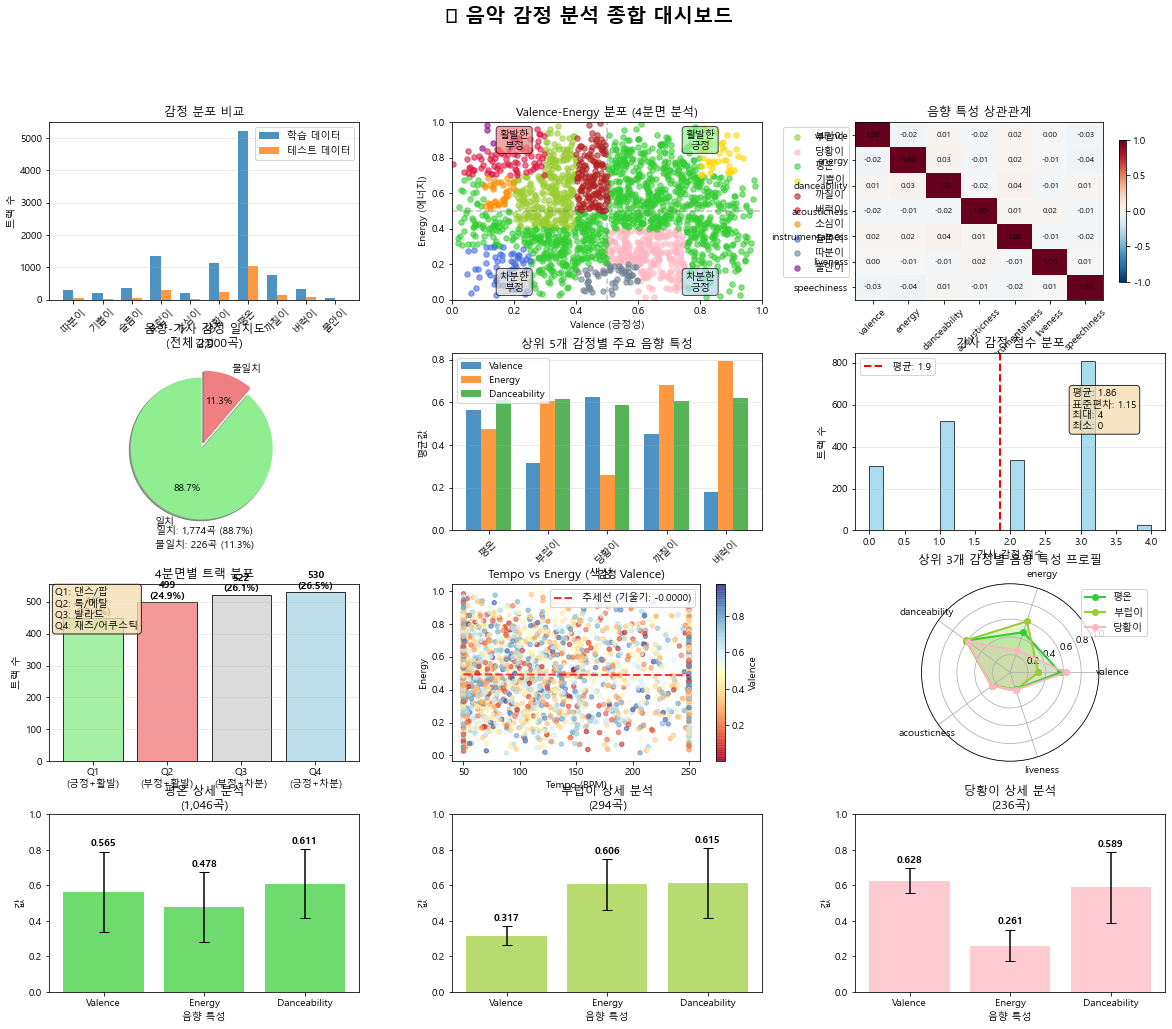


📊 종합 통계 분석 리포트

📈 데이터 개요:
   학습 데이터: 10,000 트랙
   테스트 데이터: 2,000 트랙
   총 데이터: 12,000 트랙

🎭 감정 분포 분석:
    1. 평온      : 1,046곡 ( 52.3%)
    2. 부럽이     :   294곡 ( 14.7%)
    3. 당황이     :   236곡 ( 11.8%)
    4. 까칠이     :   152곡 (  7.6%)
    5. 버럭이     :    80곡 (  4.0%)
    6. 슬픔이     :    57곡 (  2.9%)
    7. 따분이     :    55곡 (  2.8%)
    8. 기쁨이     :    38곡 (  1.9%)
    9. 소심이     :    35곡 (  1.8%)
   10. 불안이     :     7곡 (  0.4%)

🎵 음향 특성 통계:
   valence      : 평균 0.496 (±0.223) | 범위 [0.004, 0.976]
   energy       : 평균 0.491 (±0.223) | 범위 [0.014, 0.995]
   danceability : 평균 0.607 (±0.196) | 범위 [0.046, 0.997]
   acousticness : 평균 0.256 (±0.197) | 범위 [0.000, 0.907]

📝 가사 분석 통계:
   음향-가사 감정 일치: 1,774곡 (88.7%)
   불일치: 226곡 (11.3%)
   평균 가사 감정 점수: 1.86

🎯 4분면 분석:
   1사분면 (긍정+활발):  449곡 ( 22.4%) - 댄스/팝
   2사분면 (부정+활발):  499곡 ( 24.9%) - 록/메탈
   3사분면 (부정+차분):  522곡 ( 26.1%) - 발라드
   4사분면 (긍정+차분):  530곡 ( 26.5%) - 재즈/어쿠스틱

🎯 Step 4: 다양한 감정별 추천 분석...

🎵 테스트 케이스 1: 파티용 신나는 음악
감정 표현: '신나는 파티 음악!'
가사 

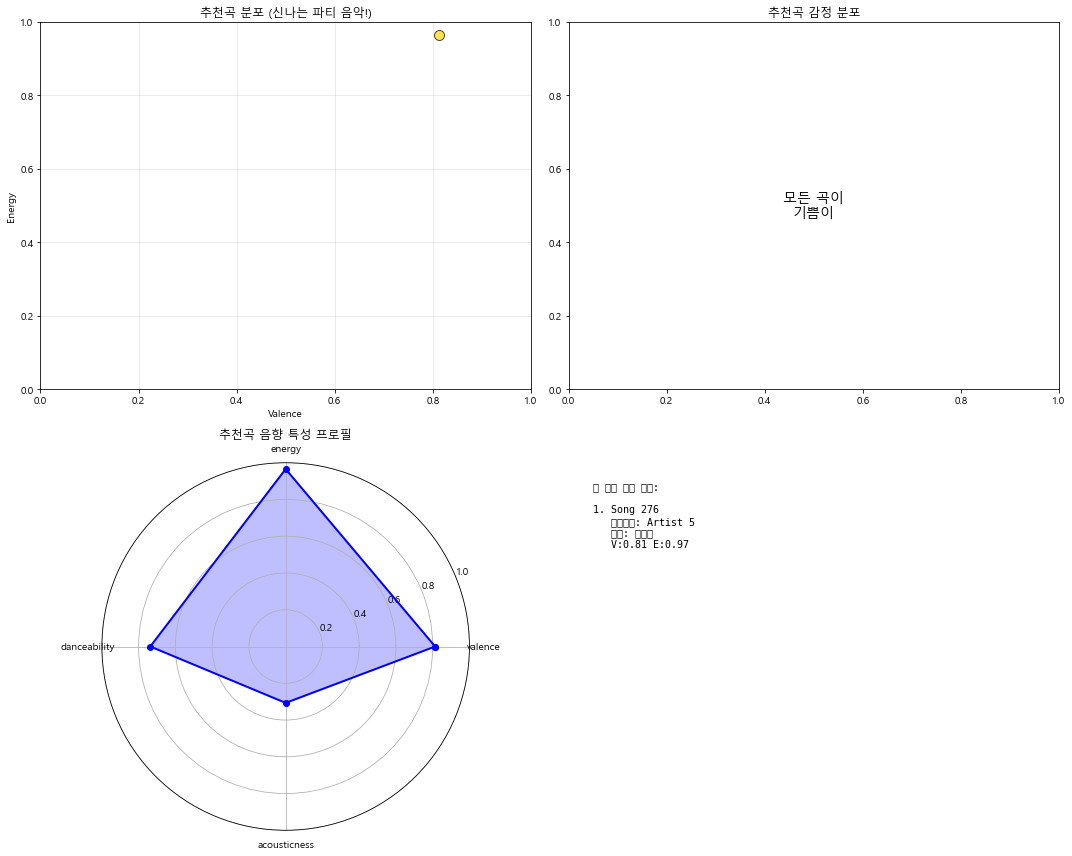


🎶 상위 5개 추천곡:
   1. Song 276 - Artist 5
      감정: 기쁨이 | V:0.813 E:0.966
      가사: 오늘은 정말 행복한 날이야 사랑하는 사람과 함께 웃음이 끊이지 않아
      가사 매칭 점수: 1
      매칭된 키워드: ['행복']


🎵 테스트 케이스 2: 이별 후 감성적인 음악
감정 표현: '이별 후 우울한 기분'
가사 키워드: '이별 슬픔 그리움'
'이별 후 우울한 기분'에서 '우울' 키워드로 '슬픔이' 감정을 감지했습니다.
🎭 감정: 슬픔이
🎵 가사 키워드: '이별 슬픔 그리움'
✅ 가사 키워드 매칭: 3곡 중 3곡 추천

🎯 '이별 후 우울한 기분' 추천 결과 상세 분석
📊 추천곡 수: 3

🎭 추천곡 감정 분포:
   슬픔이: 3곡 (100.0%)

🎵 추천곡 음향 특성 평균:
   Valence: 0.191
   Energy: 0.192
   Danceability: 0.710
   Acousticness: 0.066

📝 가사 키워드 매칭:
   매칭된 곡: 3곡
   평균 매칭 점수: 1.00


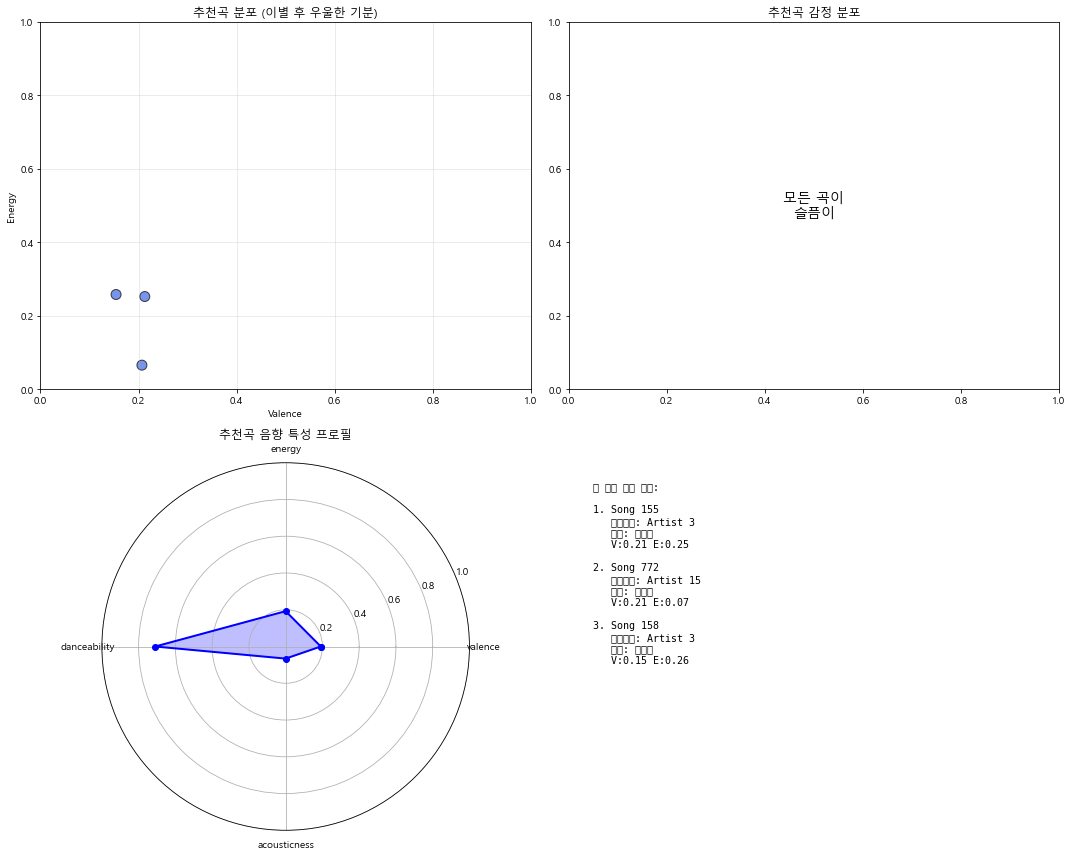


🎶 상위 5개 추천곡:
   1. Song 155 - Artist 3
      감정: 슬픔이 | V:0.213 E:0.253
      가사: 빈 방에 혼자 남겨진 채 그리움에 잠 못 이루네
      가사 매칭 점수: 1
      매칭된 키워드: ['그리움']

   2. Song 772 - Artist 15
      감정: 슬픔이 | V:0.207 E:0.066
      가사: 이별한 사람이 그리워 눈물이 흘러 외로운 밤을 보내고 있어
      가사 매칭 점수: 1
      매칭된 키워드: ['이별']

   3. Song 158 - Artist 3
      감정: 슬픔이 | V:0.154 E:0.258
      가사: 이별한 사람이 그리워 눈물이 흘러 외로운 밤을 보내고 있어
      가사 매칭 점수: 1
      매칭된 키워드: ['이별']


🎵 테스트 케이스 3: 스트레스 해소용 음악
감정 표현: '스트레스 받을 때'
가사 키워드: '화 분노 스트레스'
'스트레스 받을 때'에서 '스트레스' 키워드로 '소심이' 감정을 감지했습니다.
🎭 감정: 소심이
🎵 가사 키워드: '화 분노 스트레스'
✅ 가사 키워드 매칭: 1곡 중 1곡 추천

🎯 '스트레스 받을 때' 추천 결과 상세 분석
📊 추천곡 수: 1

🎭 추천곡 감정 분포:
   버럭이: 1곡 (100.0%)

🎵 추천곡 음향 특성 평균:
   Valence: 0.200
   Energy: 0.823
   Danceability: 0.731
   Acousticness: 0.158

📝 가사 키워드 매칭:
   매칭된 곡: 1곡
   평균 매칭 점수: 1.00


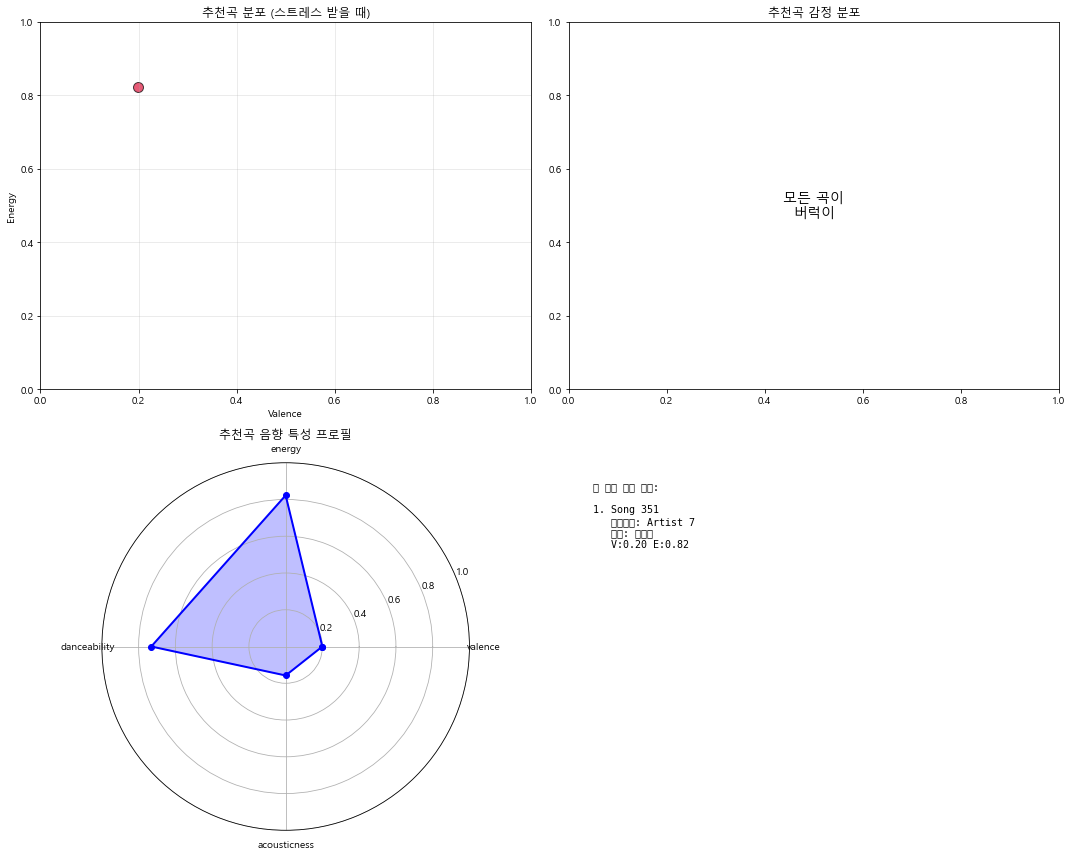


🎶 상위 5개 추천곡:
   1. Song 351 - Artist 7
      감정: 버럭이 | V:0.200 E:0.823
      가사: 억울한 마음 누구에게 말해 화만 계속 쌓여가네
      가사 매칭 점수: 1
      매칭된 키워드: ['화']


🎵 테스트 케이스 4: 휴식용 차분한 음악
감정 표현: '편안한 휴식 시간'
가사 키워드: '평온 휴식 차분'
'편안한 휴식 시간'에서 '편안' 키워드로 '평온' 감정을 감지했습니다.
🎭 감정: 평온
🎵 가사 키워드: '평온 휴식 차분'
✅ 가사 키워드 매칭: 7곡 중 7곡 추천

🎯 '편안한 휴식 시간' 추천 결과 상세 분석
📊 추천곡 수: 7

🎭 추천곡 감정 분포:
   평온: 7곡 (100.0%)

🎵 추천곡 음향 특성 평균:
   Valence: 0.593
   Energy: 0.538
   Danceability: 0.635
   Acousticness: 0.230

📝 가사 키워드 매칭:
   매칭된 곡: 7곡
   평균 매칭 점수: 1.57


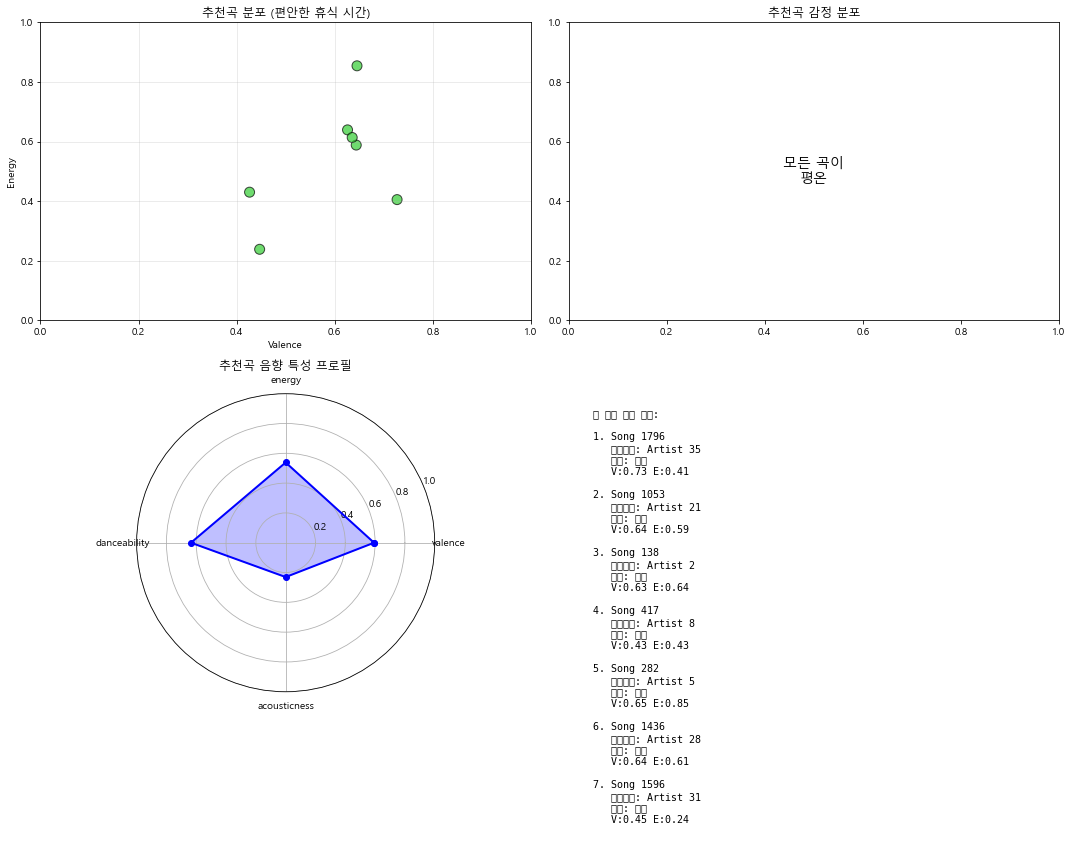


🎶 상위 5개 추천곡:
   1. Song 1796 - Artist 35
      감정: 평온 | V:0.727 E:0.405
      가사: 조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어
      가사 매칭 점수: 2
      매칭된 키워드: ['평온', '차분']

   2. Song 1053 - Artist 21
      감정: 평온 | V:0.644 E:0.588
      가사: 조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어
      가사 매칭 점수: 2
      매칭된 키워드: ['평온', '차분']

   3. Song 138 - Artist 2
      감정: 평온 | V:0.626 E:0.639
      가사: 조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어
      가사 매칭 점수: 2
      매칭된 키워드: ['평온', '차분']

   4. Song 417 - Artist 8
      감정: 평온 | V:0.426 E:0.430
      가사: 조용한 카페에서 차분하게 책을 읽으며 평온한 시간을 보내고 있어
      가사 매칭 점수: 2
      매칭된 키워드: ['평온', '차분']

   5. Song 282 - Artist 5
      감정: 평온 | V:0.645 E:0.854
      가사: 여유로운 오후 따뜻한 햇살 아래 편안한 휴식
      가사 매칭 점수: 1
      매칭된 키워드: ['휴식']


🎵 테스트 케이스 5: 운동용 에너지 넘치는 음악
감정 표현: '운동할 때'

🎯 '운동할 때' 추천 결과 상세 분석
📊 추천곡 수: 8

🎭 추천곡 감정 분포:
   평온: 5곡 (62.5%)
   당황이: 2곡 (25.0%)
   따분이: 1곡 (12.5%)

🎵 추천곡 음향 특성 평균:
   Valence: 0.591
   Energy: 0.412
   Danceability: 0.517
   Acousticness: 0.287

📝 

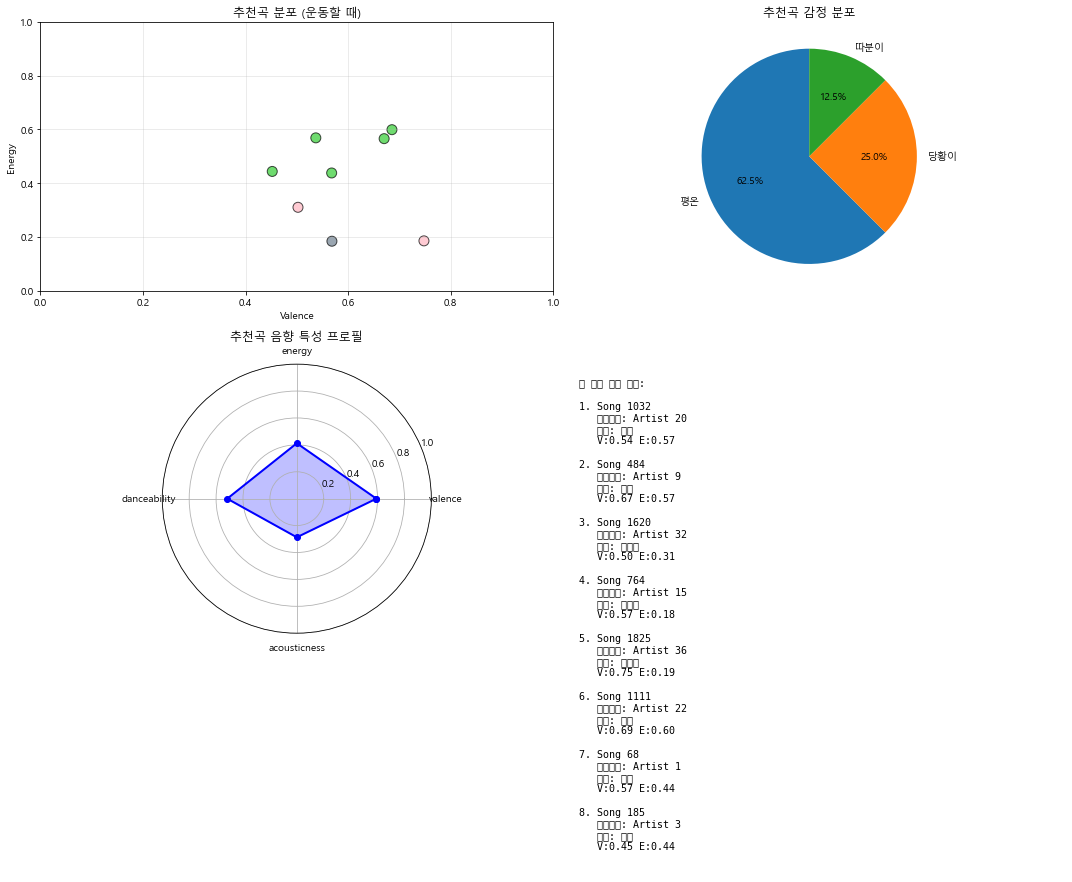


🎶 상위 5개 추천곡:
   1. Song 1032 - Artist 20
      감정: 평온 | V:0.537 E:0.569
      가사: 세상의 소음을 멀리하고 내 마음의 소리에 귀 기울여

   2. Song 484 - Artist 9
      감정: 평온 | V:0.670 E:0.566
      가사: 고요한 자연 속에서 마음의 평화를 찾아가네
      가사 매칭 점수: 3

   3. Song 1620 - Artist 32
      감정: 당황이 | V:0.502 E:0.310
      가사: 어색한 상황에 처해서 어떻게 행동해야 할지 모르겠어
      가사 매칭 점수: 1

   4. Song 764 - Artist 15
      감정: 따분이 | V:0.568 E:0.184
      가사: 심심해서 뭘 해야 할지 모르겠어 지루한 하루
      가사 매칭 점수: 2

   5. Song 1825 - Artist 36
      감정: 당황이 | V:0.748 E:0.186
      가사: 창피한 순간이 자꾸 생각나 민망해서 어쩔 줄 모르겠어
      가사 매칭 점수: 2


🎭 Step 5: 감정 예측 상세 분석

🎯 음향 특성 기반 감정 예측 테스트:

1. 매우 밝고 에너지 넘치는 댄스 팝
   음향 특성: [0.9, 0.8, 0.8, 0.2, 0.1, 0.2, 0.1, -4.0, 140.0]
   🎭 예측 결과: 평온 (신뢰도: 1.000)
   🎯 예상 결과: 기쁨이
   ✅ 정확도: 틀림
   📊 상위 3개 감정 확률:
      1. 평온: 1.000 ███████████████
      2. 슬픔이: 0.000 
      3. 소심이: 0.000 

2. 어쿠스틱한 슬픈 발라드
   음향 특성: [0.15, 0.25, 0.3, 0.9, 0.05, 0.1, 0.03, -15.0, 65.0]
   🎭 예측 결과: 슬픔이 (신뢰도: 1.000)
   🎯 예상 결과: 슬픔이
   ✅ 정확도: 맞음
   📊 상위 3

In [36]:
detailed_demo_with_comprehensive_analysis()